# Modelado de Farmacóforos — Proteasa del VIH-1 / UP4

**Autor:** Eduardo Cubillos-Llantén  
**Programa:** Bioinformática — Biomedicina y Biofarmacéutica  
**Nivel:** Pregrado avanzado / Posgrado inicial  
**Versión:** 1.0 — 2026

---

## Mapa del notebook

```
Celda  1  -- Instalacion de dependencias
Celda  2  -- Descarga PDB 6X48 + SMILES de UP4
Celda  3  -- MODELO 1: SBP con PLIP + fallback BioPython
Celda  4  -- MODELO 2: LBP con RDKit
Celda  5  -- Visualizacion SBP (complejo proteina-ligando)
Celda  6  -- Clustering SBP: antes y despues
Celda  7  -- Visualizacion LBP
Celda  8  -- Clustering LBP
Celda  9  -- Comparativa SBP vs LBP + superposicion de coordenadas
Celda 10  -- MODELO 3: RBP — sitio activo, pH 7.4, protonacion
Celda 11  -- Visualizacion RBP (perspectiva del receptor)
Celda 12  -- Comparativa SBP vs LBP vs RBP
Celda 13  -- Superposicion de los tres modelos
Celda 14  -- Exportacion PDB individual (SBP, LBP, RBP)
Celda 15  -- MODELO CONSENSO: algoritmo con complementariedad fisica
Celda 16  -- Visualizacion 3D del consenso
Celda 17  -- Conclusiones y ejercicios
```

---

## Licencia

```
Copyright (c) 2026 — Eduardo Cubillos-Llantén
Programa de Bioinformática — Biomedicina y Biofarmacéutica

Licencia: Creative Commons Attribution-NonCommercial-ShareAlike 4.0 (CC BY-NC-SA 4.0)

Permitido:
  - Uso con fines educativos no comerciales
  - Adaptacion y mejora citando la fuente original
  - Redistribucion bajo la misma licencia

No permitido:
  - Uso comercial sin autorizacion expresa
  - Redistribucion como material propio sin atribucion

```

---

---
## Celda 1 — Instalacion de dependencias

### Que instalamos y por que

| Libreria | Funcion en este notebook |
|----------|--------------------------|
| **RDKit** | Quimioinformatica: parsear SMILES, generar conformaciones 3D, extraer features LBP [3] |
| **BioPython** | Leer archivos PDB, navegar la jerarquia Modelo→Cadena→Residuo→Atomo [4] |
| **PLIP** | Protein-Ligand Interaction Profiler: detecta H-bonds, contactos hidrofobicos, etc. [5] |
| **py3Dmol** | Visualizacion 3D interactiva basada en WebGL [6] |
| **openbabel-wheel** | Conversion de formatos moleculares; requerida internamente por PLIP |

In [1]:
"""
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# INSTALACIÓN DE DEPENDENCIAS — Estrategia robusta para Colab
# ─────────────────────────────────────────────────────────────
import subprocess, sys, shutil, os

def run(cmd, check=True):
    """"""Ejecuta un comando de shell, imprime output si falla.""""""
    r = subprocess.run(cmd, capture_output=True, text=True)
    if check and r.returncode != 0:
        print(f"  STDERR: {r.stderr[-400:]}")
    return r

def pip(*pkgs, extra_flags=None):
    flags = extra_flags or []
    run([sys.executable, "-m", "pip", "install", "-q", *flags, *pkgs])

# ── Paquetes estándar ─────────────────────────────────────────
print("[1/5] Instalando rdkit, py3Dmol, biopython, requests, lxml...")
pip("rdkit", "py3Dmol", "biopython", "requests", "lxml", "pandas")
print("      OK")

# ── openbabel-wheel primero (binarios precompilados) ──────────
print("[2/5] Instalando openbabel-wheel...")
pip("openbabel-wheel")
print("      OK")

# ── PLIP: intentar varias estrategias en orden ────────────────
print("[3/5] Instalando PLIP...")

plip_ok = False

# Estrategia 1: pip normal
r1 = run([sys.executable, "-m", "pip", "install", "-q", "plip"], check=False)
if r1.returncode == 0 and shutil.which("plip"):
    print("      PLIP instalado (pip directo)")
    plip_ok = True

# Estrategia 2: pip --no-deps (evita conflictos con openbabel)
if not plip_ok:
    r2 = run([sys.executable, "-m", "pip", "install", "-q",
              "--no-deps", "plip"], check=False)
    # Instalar las deps de PLIP manualmente excepto openbabel
    pip("numpy", "lxml", "matplotlib", extra_flags=["--no-deps"])
    if r2.returncode == 0:
        print("      PLIP instalado (pip --no-deps)")
        plip_ok = True

# Estrategia 3: clonar desde GitHub y ejecutar directamente
if not plip_ok:
    print("      pip falla, clonando desde GitHub...")
    if not os.path.exists("/content/plip"):
        r3 = run(["git", "clone", "--depth", "1",
                  "https://github.com/pharmai/plip.git",
                  "/content/plip"], check=False)
        if r3.returncode == 0:
            # Agregar al PATH para poder llamar 'python /content/plip/plip/plipcmd.py'
            sys.path.insert(0, "/content/plip")
            print("      PLIP clonado en /content/plip")
            plip_ok = True
        else:
            print("      ERROR: clone tambien fallo")
    else:
        sys.path.insert(0, "/content/plip")
        print("      PLIP ya disponible en /content/plip")
        plip_ok = True

if not plip_ok:
    print(" PLIP no disponible. Se usará el fallback BioPython para el SBP.")
    print("     Esto NO afecta el LBP ni la visualización.")

# ── Verificar comando plip en PATH ────────────────────────────
plip_cmd = shutil.which("plip")
if plip_cmd:
    print(f"    Ejecutable PLIP encontrado: {plip_cmd}")
else:
    # Buscar el script plipcmd.py si se clono
    alt = "/content/plip/plip/plipcmd.py"
    plip_cmd = alt if os.path.exists(alt) else None
    if plip_cmd:
        print(f"    PLIP disponible como script: {plip_cmd}")
    else:
        print("    PLIP no encontrado, se usara el fallback BioPython")

print("\nInstalacion completa")
print(f"   PLIP disponible: {'Sí → ' + str(plip_cmd) if plip_cmd else 'No (fallback activo)'}")
"""

'\n# ─────────────────────────────────────────────────────────────────────────\n# Farmacóforos VIH-1/UP4 — Notebook educativo\n# Autor: Eduardo Cubillos-Llantén\n# Programa: Bioinformática — Biomedicina y Biofarmacéutica\n# Año: 2026\n# Licencia: CC BY-NC-SA 4.0\n# ─────────────────────────────────────────────────────────────────────────\n# ─────────────────────────────────────────────────────────────\n# INSTALACIÓN DE DEPENDENCIAS — Estrategia robusta para Colab\n# ─────────────────────────────────────────────────────────────\nimport subprocess, sys, shutil, os\n\ndef run(cmd, check=True):\n    Ejecuta un comando de shell, imprime output si falla.\n    r = subprocess.run(cmd, capture_output=True, text=True)\n    if check and r.returncode != 0:\n        print(f"  STDERR: {r.stderr[-400:]}")\n    return r\n\ndef pip(*pkgs, extra_flags=None):\n    flags = extra_flags or []\n    run([sys.executable, "-m", "pip", "install", "-q", *flags, *pkgs])\n\n# ── Paquetes estándar ──────────────────

---
## Celda 2 — Descarga del complejo 6X48 y SMILES de UP4



In [2]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import requests
import os
import subprocess, sys, shutil, os

# ─────────────────────────────────────────────────────────────
# DESCARGA DEL PDB
# ─────────────────────────────────────────────────────────────
PDB_ID  = "6X48"
PDB_URL = f"https://files.rcsb.org/download/{PDB_ID}.pdb"
PDB_FILE = f"{PDB_ID}.pdb"

if not os.path.exists(PDB_FILE):
    response = requests.get(PDB_URL, timeout=30)
    response.raise_for_status()
    with open(PDB_FILE, "w") as fh:
        fh.write(response.text)
    print(f"Descargado {PDB_FILE} ({len(response.text):,} caracteres)")
else:
    print(f"{PDB_FILE} ya existe en disco, se omite la descarga.")

# ─────────────────────────────────────────────────────────────
# SMILES CANÓNICO DE UP4
# Fuente: PubChem CID 392622, con corrección de numeración de anillos para RDKit
# ─────────────────────────────────────────────────────────────
LIGANDO_SMILES = (
    "C(NC(c1cc(Cl)cc(Cl)c1)=O)(C(=O)O)CCC(C)(C)C"
)

lig_res_id = "UP4"

# ─────────────────────────────────────────────────────────────
# LECTURA CON BIOPYTHON — INVENTARIO DEL COMPLEJO
# ─────────────────────────────────────────────────────────────
from Bio.PDB import PDBParser
import warnings
warnings.filterwarnings("ignore")  # suprime avisos de residuos no estándares

parser  = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, PDB_FILE)
model   = structure[0]

# Listar heteroátomos (ligandos y cofactores)
print("\nHeteroatomos en 6X48:")
seen = set()
for chain in model:
    for res in chain:
        rname = res.get_resname().strip()
        if res.id[0] not in (" ", "W") and rname not in seen:
            seen.add(rname)
            natoms = len(list(res.get_atoms()))
            print(f"  Cadena {chain.id} | Residuo: {rname:5s} | {natoms} átomos")

# Contar residuos proteicos
n_prot = sum(1 for c in model for r in c if r.id[0] == " ")
print(f"Residuos proteicos: {n_prot}")

Descargado 6X48.pdb (478,224 caracteres)

Heteroatomos en 6X48:
  Cadena A | Residuo: UP4   | 21 átomos
  Cadena A | Residuo: UNL   | 18 átomos
  Cadena A | Residuo: GOL   | 6 átomos
  Cadena B | Residuo: NAG   | 14 átomos
  Cadena B | Residuo: BMA   | 11 átomos
  Cadena B | Residuo: MAN   | 11 átomos
Residuos proteicos: 654


---
## Celda 3 — Modelo 1: SBP (Farmacoforo Basado en Estructura)
---


In [3]:
import subprocess
import xml.etree.ElementTree as ET
import numpy as np

# ─────────────────────────────────────────────────────────────
# EJECUCIÓN DE PLIP VÍA CLI
# -f : archivo PDB de entrada
# -x : generar reporte en formato XML (más fácil de parsear)
# -o : directorio de salida (flag lowercase; -O sin argumento es invalido en algunas versiones)
# ─────────────────────────────────────────────────────────────
PLIP_OUTDIR = "plip_output"
os.makedirs(PLIP_OUTDIR, exist_ok=True)

# Recuperar plip_cmd de la Celda 1; si no existe, buscar manualmente
try:
    _pc = plip_cmd
except NameError:
    import shutil as _sh
    _pc = _sh.which("plip")
    if not _pc and os.path.exists("/content/plip/plip/plipcmd.py"):
        _pc = "/content/plip/plip/plipcmd.py"

if _pc and _pc.endswith(".py"):
    cmd = [sys.executable, _pc, "-f", PDB_FILE, "-x", "-o", PLIP_OUTDIR]
elif _pc:
    cmd = [_pc, "-f", PDB_FILE, "-x", "-o", PLIP_OUTDIR]
else:
    cmd = None

plip_ok = False
if cmd:
    print(f"Ejecutando PLIP: {' '.join(cmd)}")

    # Set PYTHONPATH for the subprocess to find PLIP modules
    env = os.environ.copy()
    # Add /content/plip to PYTHONPATH so plip.plipcmd.py can find its own modules
    env["PYTHONPATH"] = "/content/plip:" + env.get("PYTHONPATH", "")

    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    plip_ok = (result.returncode == 0)
    if plip_ok:
        print("PLIP: ejecucion completada")
    else:
        print("PLIP: termino con errores, activando fallback BioPython")
        print("STDERR:", result.stderr[:500])
else:
    print("PLIP no encontrado, usando fallback BioPython")


# ─────────────────────────────────────────────────────────────
# PARSEO DEL XML DE PLIP
# El XML tiene la estructura:
#   <report>
#     <bindingsite>
#       <interactions>
#         <hydrophobic_interactions> ...
#         <hydrogen_bonds> ...
# ─────────────────────────────────────────────────────────────

# Contenedor para los features del SBP
# Cada feature: {'type': str, 'coords': (x, y, z), 'label': str}
sbp_features = []

def parse_plip_xml(xml_dir):
    """Busca el XML de PLIP y extrae coordenadas de features."""
    features = []
    xml_files = [f for f in os.listdir(xml_dir) if f.endswith(".xml")]
    if not xml_files:
        print("  No se encontraron archivos XML en", xml_dir)
        return features

    for xf in xml_files:
        print(f"  Parseando: {xf}")
        tree = ET.parse(os.path.join(xml_dir, xf))
        root = tree.getroot()

        # ── Contactos hidrofóbicos ──────────────────────────────
        for hydroph in root.iter("hydrophobic_interaction"):
            try:
                # Corrected: PLIP uses ligc_x, ligc_y, ligc_z for hydrophobic ligand atoms
                x = float(hydroph.findtext("ligc_x") or 0)
                y = float(hydroph.findtext("ligc_y") or 0)
                z = float(hydroph.findtext("ligc_z") or 0)
                atom_id = hydroph.findtext("lig_atom_idx") or "?"
                if (x, y, z) != (0.0, 0.0, 0.0):
                    features.append({
                        "type": "HYDROPHOBIC",
                        "coords": (x, y, z),
                        "label": f"Hidrofóbico (lig_atom {atom_id})"
                    })
            except (TypeError, ValueError):
                continue

        # ── Puentes de hidrógeno ───────────────────────────────
        for hbond in root.iter("hydrogen_bond"):
            try:
                # donor_flag: 'True' si el ligando es el donor
                lig_is_donor = (hbond.findtext("protisdon") or "").lower() == "false"
                x = float(hbond.findtext("lig_x") or 0)
                y = float(hbond.findtext("lig_y") or 0)
                z = float(hbond.findtext("lig_z") or 0)
                dist  = hbond.findtext("dist_h-a") or hbond.findtext("dist_d-a") or "?"
                angle = hbond.findtext("angle") or "?"
                ftype = "DONOR" if lig_is_donor else "ACCEPTOR"
                if (x, y, z) != (0.0, 0.0, 0.0):
                    features.append({
                        "type": ftype,
                        "coords": (x, y, z),
                        "label": f"{ftype} d={dist}Å θ={angle}°"
                    })
            except (TypeError, ValueError):
                continue

    return features

# ─────────────────────────────────────────────────────────────
# EXTRACCIÓN DE RESPALDO: Si PLIP falla, calculamos contactos
# con BioPython midiendo distancias atómicas directamente.
# ─────────────────────────────────────────────────────────────

HYDROPHOBIC_ELEMENTS = {"C", "S"}  # átomos considerados hidrofóbicos
HBOND_DONOR_ATOMS     = {"N", "O"}  # átomos que pueden ser donadores
HBOND_DIST_CUTOFF    = 3.5         # Å — umbral H-bond
HYDROPH_DIST_CUTOFF  = 4.0         # Å — umbral contacto hidrofóbico

def fallback_sbp_from_biopython(structure, ligand_resname="UP4"): # Changed default from 'UP4' to 'UP4'
    """
    Extracción manual de features SBP usando distancias atómicas.
    Menos precisa que PLIP (no calcula ángulos), pero robusta.
    """
    features = []
    model = structure[0]

    # Recolectar átomos del ligando
    lig_atoms  = []
    prot_atoms = []

    # Retrieve ligand atoms from the structure based on resname 'UP4'
    for chain in model:
        for res in chain:
            if res.get_resname().strip() == ligand_resname:
                lig_atoms.extend(res.get_atoms())
            elif res.id[0] == " ":  # residuo proteico
                prot_atoms.extend(res.get_atoms())

    if not lig_atoms:
        print(f"        No se encontraron atomos para el ligando '{ligand_resname}'. Verifique el nombre del residuo.")
        return features

    print(f"  Ligando '{ligand_resname}': {len(lig_atoms)} átomos")
    print(f"  Proteína: {len(prot_atoms)} átomos")

    added_coords = set()  # evitar duplicados exactos

    for la in lig_atoms:
        la_elem  = la.element.strip() if la.element else la.get_name()[0] # element can be None
        la_coord = tuple(np.round(la.get_vector().get_array(), 2))

        for pa in prot_atoms:
            pa_elem = pa.element.strip() if pa.element else pa.get_name()[0] # element can be None
            dist    = la - pa  # BioPython sobrecarga __sub__ como distancia

            # H-bond: ambos átomos deben ser N u O
            # For BioPython fallback, we simplify: if a ligand atom is a potential donor/acceptor
            # and is close to a protein atom that is also a potential donor/acceptor.
            # We assign the type based on the ligand atom's common role.
            if (dist <= HBOND_DIST_CUTOFF
                    and la_elem in HBOND_DONOR_ATOMS
                    and pa_elem in HBOND_DONOR_ATOMS
                    and la_coord not in added_coords):
                # Simplified assignment: if it's N, likely a Donor; if O, likely an Acceptor
                ftype = "DONOR" if la_elem == "N" else "ACCEPTOR"
                features.append({
                    "type": ftype,
                    "coords": la_coord,
                    "label": f"{ftype} (respaldo, d={dist:.2f}Å)"
                })
                added_coords.add(la_coord)

            # Contacto hidrofóbico: ambos átomos C o S
            if (dist <= HYDROPH_DIST_CUTOFF
                    and la_elem in HYDROPHOBIC_ELEMENTS
                    and pa_elem in HYDROPHOBIC_ELEMENTS
                    and la_coord not in added_coords):
                features.append({
                    "type": "HYDROPHOBIC",
                    "coords": la_coord,
                    "label": f"Hidrofóbico (respaldo, d={dist:.2f}Å)"
                })
                added_coords.add(la_coord)

    return features


# ─────────────────────────────────────────────────────────────
# SELECCIÓN DE MÉTODO
# ─────────────────────────────────────────────────────────────
if plip_ok:
    sbp_features = parse_plip_xml(PLIP_OUTDIR)
    if not sbp_features:
        print("XML de PLIP sin features, activando BioPython")
        sbp_features = fallback_sbp_from_biopython(structure)
    else:
        print(f"PLIP: {len(sbp_features)} features extraidos del XML")
else:
    print(" Extrayendo features SBP con BioPython (respaldo)...")
    sbp_features = fallback_sbp_from_biopython(structure)

# ─────────────────────────────────────────────────────────────
# RESUMEN DE FEATURES SBP
# ─────────────────────────────────────────────────────────────
from collections import Counter
counts = Counter(f["type"] for f in sbp_features)

print("\n Resumen de features SBP:")
print(f"  DONOR        (azul)    : {counts.get('DONOR', 0)}")
print(f"  ACCEPTOR     (rojo)    : {counts.get('ACCEPTOR', 0)}")
print(f"  HYDROPHOBIC  (amarillo): {counts.get('HYDROPHOBIC', 0)}")
print(f"  TOTAL                  : {len(sbp_features)}")

print("\n Coordenadas de features SBP:")
for i, feat in enumerate(sbp_features):
    x, y, z = feat["coords"]
    print(f"  [{i+1:02d}] {feat['type']:12s}  ({x:7.3f}, {y:7.3f}, {z:7.3f})  {feat['label']}")

Ejecutando PLIP: C:\Users\Kiki\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe /content/plip/plip/plipcmd.py -f 6X48.pdb -x -o plip_output
PLIP: termino con errores, activando fallback BioPython
STDERR: Traceback (most recent call last):
  File "c:\content\plip\plip\plipcmd.py", line 17, in <module>
    from plip.basic import config, logger
ModuleNotFoundError: No module named 'plip'

 Extrayendo features SBP con BioPython (respaldo)...
  Ligando 'UP4': 21 átomos
  Proteína: 5143 átomos

 Resumen de features SBP:
  DONOR        (azul)    : 1
  ACCEPTOR     (rojo)    : 2
  HYDROPHOBIC  (amarillo): 5
  TOTAL                  : 8

 Coordenadas de features SBP:
  [01] HYDROPHOBIC   (-34.230,  40.140,  13.390)  Hidrofóbico (respaldo, d=3.82Å)
  [02] HYDROPHOBIC   (-29.390,  39.170,  12.320)  Hidrofóbico (respaldo, d=3.85Å)
  [03] HYDROPHOBIC   (-27.970,  40.400,  13.930)  Hidrofóbico (respaldo, d=3.66Å)
  [04] HYDROPHOBIC   (-33.360,  36.220

---
## Celda 4 — Modelo 2: LBP (Farmacoforo Basado en Ligando)
---


Molecula 2D: 21 átomos pesados, 21 enlaces
Conformacion 3D generada y minimizada con MMFF94

--- Features LBP (RDKit) ---
  DONOR        (azul)    : 2
  ACCEPTOR     (rojo)    : 4
  HYDROPHOBIC  (amarillo): 9
  TOTAL                  : 15

Primeros 10 features LBP:
  [01] DONOR         (  1.333,   0.737,  -0.492)  ← Donor
  [02] DONOR         (  0.787,   3.180,  -1.020)  ← Donor
  [03] ACCEPTOR      (  1.485,  -1.486,  -1.010)  ← Acceptor
  [04] ACCEPTOR      ( -1.275,   2.884,  -1.804)  ← Acceptor
  [05] ACCEPTOR      (  0.787,   3.180,  -1.020)  ← Acceptor
  [06] ACCEPTOR      ( -0.252,   2.816,  -1.385)  ← NegIonizable
  [07] HYDROPHOBIC   (  4.744,  -0.540,   0.312)  ← Aromatic
  [08] HYDROPHOBIC   (  3.409,  -0.479,  -0.104)  ← Hydrophobe
  [09] HYDROPHOBIC   (  5.223,   0.367,   1.247)  ← Hydrophobe
  [10] HYDROPHOBIC   (  5.596,  -1.506,  -0.212)  ← Hydrophobe


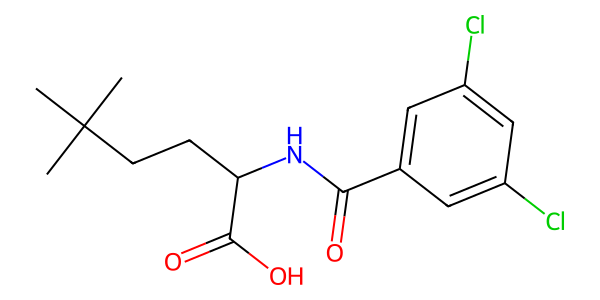

Figura: Estructura 2D del UP4 (SMILES → RDKit)


In [4]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem import ChemicalFeatures
from rdkit import RDConfig
import os as _os
import numpy as np
from collections import Counter # Added: Import Counter for later use
import sys # Added: For printing warnings to stderr

# ─────────────────────────────────────────────────────────────
# 1. PARSEO DEL SMILES
# ─────────────────────────────────────────────────────────────
mol2d = Chem.MolFromSmiles(LIGANDO_SMILES, sanitize=False) # Changed: Initial parse without sanitization
if mol2d is not None:
    try:
        Chem.SanitizeMol(mol2d) # Attempt sanitization explicitly
    except Exception as e:
        mol2d = None # If sanitization fails, treat as invalid
        print(f"Warning: RDKit sanitization failed after MolFromSmiles(sanitize=False). Error: {e}", file=sys.stderr)
else:
    print("Warning: RDKit failed to parse SMILES even without sanitization.", file=sys.stderr)
assert mol2d is not None, "Error: SMILES inválido"
print(f"Molecula 2D: {mol2d.GetNumAtoms()} átomos pesados, "
      f"{mol2d.GetNumBonds()} enlaces")

# ─────────────────────────────────────────────────────────────
# 2. GENERACIÓN DE CONFORMACIÓN 3D
# AddHs: agrega hidrógenos explícitos (necesarios para H-bonds)
# EmbedMolecule: genera coordenadas 3D con el algoritmo ETKDG
# MMFFOptimizeMolecule: minimización energética con campo de fuerzas MMFF94
# ─────────────────────────────────────────────────────────────
mol3d = Chem.AddHs(mol2d)
params = AllChem.ETKDGv3()   # versión mejorada del generador de conformaciones
params.randomSeed = 42
embed_status = AllChem.EmbedMolecule(mol3d, params)

if embed_status == 0:
    AllChem.MMFFOptimizeMolecule(mol3d, maxIters=2000)
    print("Conformacion 3D generada y minimizada con MMFF94")
else:
    print("EmbedMolecule fallo, reintentando con coordenadas aleatorias")
    AllChem.EmbedMolecule(mol3d, AllChem.ETKDG())

# Remover H para features (trabajan con átomos pesados principalmente)
mol_noH = Chem.RemoveHs(mol3d)
conf    = mol_noH.GetConformer()

# ─────────────────────────────────────────────────────────────
# 3. CÁLCULO DE FEATURES FARMACOFÓRICOS
# BaseFeatures.fdef es el archivo de definiciones SMARTS de RDKit
# ─────────────────────────────────────────────────────────────
fdef_path = _os.path.join(RDConfig.RDDataDir, "BaseFeatures.fdef")
factory   = ChemicalFeatures.BuildFeatureFactory(fdef_path)
features  = factory.GetFeaturesForMol(mol_noH)

# ─────────────────────────────────────────────────────────────
# 4. MAPEO AL ESQUEMA DE COLORES DEL SBP
# Para comparar SBP y LBP usamos los mismos tipos:
#   ACCEPTOR, DONOR, HYDROPHOBIC
# ─────────────────────────────────────────────────────────────
FTYPE_MAP = {
    "Acceptor"    : "ACCEPTOR",
    "Donor"       : "DONOR",
    "Hydrophobe"  : "HYDROPHOBIC",
    "LumpedHydrophobe": "HYDROPHOBIC",
    "PosIonizable": "DONOR",      # asimilamos a donor para visualización
    "NegIonizable": "ACCEPTOR",
    "Aromatic"    : "HYDROPHOBIC",
}

lbp_features = []
for feat in features:
    fname = feat.GetFamily()          # 'Donor', 'Acceptor', etc.
    ftype = FTYPE_MAP.get(fname, None)
    if ftype is None:
        continue
    # La posición del feature = centroide de los átomos participantes
    atom_ids = list(feat.GetAtomIds())
    coords   = [conf.GetAtomPosition(idx) for idx in atom_ids]
    cx = float(np.mean([c.x for c in coords]))
    cy = float(np.mean([c.y for c in coords]))
    cz = float(np.mean([c.z for c in coords]))
    lbp_features.append({
        "type"  : ftype,
        "family": fname,
        "coords": (cx, cy, cz),
        "atoms" : atom_ids,
        "label" : f"{fname} (átomos: {atom_ids})"
    })

# ─────────────────────────────────────────────────────────────
# 5. RESUMEN
# ─────────────────────────────────────────────────────────────
lbp_counts = Counter(f["type"] for f in lbp_features)
print("\n--- Features LBP (RDKit) ---")
print(f"  DONOR        (azul)    : {lbp_counts.get('DONOR', 0)}")
print(f"  ACCEPTOR     (rojo)    : {lbp_counts.get('ACCEPTOR', 0)}")
print(f"  HYDROPHOBIC  (amarillo): {lbp_counts.get('HYDROPHOBIC', 0)}")
print(f"  TOTAL                  : {len(lbp_features)}")

print("\nPrimeros 10 features LBP:")
for i, feat in enumerate(lbp_features[:10]):
    x, y, z = feat["coords"]
    print(f"  [{i+1:02d}] {feat['type']:12s}  ({x:7.3f}, {y:7.3f}, {z:7.3f})  ← {feat['family']}")

# ─────────────────────────────────────────────────────────────
# 6. VISUALIZACIÓN 2D DE UP4 EN EL NOTEBOOK
# ─────────────────────────────────────────────────────────────
from IPython.display import display
img = Draw.MolToImage(mol2d, size=(600, 300))
display(img)
print("Figura: Estructura 2D del UP4 (SMILES → RDKit)")

---
## Celda 5 — Visualizacion 3D del SBP: features originales
---

In [5]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import py3Dmol
from IPython.display import display, HTML
import numpy as np # Necesario para cálculos de distancia
from Bio.PDB import PDBIO, Select
import io # Para manejar el PDB en memoria

# ─────────────────────────────────────────────────────────────
# CARGA DEL PDB COMPLETO (original) para otros usos si es necesario
# ─────────────────────────────────────────────────────────────
with open(PDB_FILE, "r") as fh:
    pdb_text = fh.read()

# ─────────────────────────────────────────────────────────────
# GENERAR PDB SOLO CON LA PROTEÍNA para Visualización 1
# ─────────────────────────────────────────────────────────────
class ProteinOnlySelect(Select):
    def accept_residue(self, residue):
        # Acepta solo residuos proteicos (no heteroátomos como ligandos o agua)
        return residue.id[0] == " "

protein_only_pdb_io = io.StringIO()
pdb_writer = PDBIO()
pdb_writer.set_structure(structure) # 'structure' es global de download-cell
pdb_writer.save(protein_only_pdb_io, ProteinOnlySelect())
protein_only_pdb_text = protein_only_pdb_io.getvalue()

# ─────────────────────────────────────────────────────────────
# MAPA DE COLORES
# ─────────────────────────────────────────────────────────────n
COLOR_MAP = {
    "ACCEPTOR"   : "red",
    "DONOR"      : "blue",
    "HYDROPHOBIC": "yellow",
}
SPHERE_RADIUS = 1.0   # Å — radio de cada esfera farmacofórica

def add_pharmacophore_spheres(view, features, radius=SPHERE_RADIUS, opacity=0.6):
    """
    Añade esferas translúcidas al visor py3Dmol para cada feature farmacofórico.

    Parámetros:
        view     : objeto py3Dmol.view
        features : lista de dicts {'type', 'coords', 'label'}
        radius   : radio de la esfera en Ångstroms
        opacity  : transparencia (0=invisible, 1=sólido)
    """
    for feat in features:
        x, y, z = [float(c) for c in feat["coords"]]
        color    = COLOR_MAP.get(feat["type"], "green")
        view.addSphere({
            "center": {"x": x, "y": y, "z": z},
            "radius": radius,
            "color" : color,
            "opacity": opacity,
        })

# Define un radio de agrupación global para todos los tipos de features
GLOBAL_CLUSTER_RADIUS = 5.0 # Usamos el último valor solicitado por el usuario

def _cluster_features_of_same_type(features_of_one_type, cluster_radius_for_type):
    """
    Agrupa features de un mismo tipo que están muy cercanos en un único feature (centroide).
    """
    if not features_of_one_type:
        return []

    clustered_features = []
    processed_indices = set()

    current_features = list(features_of_one_type) # Crear una copia para iterar

    for i, f1 in enumerate(current_features):
        if i in processed_indices:
            continue

        cluster = [f1]
        processed_indices.add(i)

        f1_coords = np.array(f1["coords"], dtype=float)
        current_type = f1["type"]

        for j, f2 in enumerate(current_features):
            if j == i or j in processed_indices:
                continue

            f2_coords = np.array(f2["coords"], dtype=float)
            distance = np.linalg.norm(f1_coords - f2_coords)

            if distance < cluster_radius_for_type:
                cluster.append(f2)
                processed_indices.add(j)

        centroid_coords = np.mean([np.array(f["coords"]) for f in cluster], axis=0)

        clustered_features.append({
            "type": current_type,
            "coords": tuple(centroid_coords),
            "label": f"{current_type} agrupado (de {len(cluster)} features)"
        })

    return clustered_features

def cluster_all_pharmacophore_types(all_features, global_cluster_radius):
    """
    Aplica el clustering a todos los tipos de features farmacofóricos por separado,
    usando un único radio de agrupación para todos los tipos.
    """
    grouped_features = {}
    for feat in all_features:
        grouped_features.setdefault(feat["type"], []).append(feat)

    final_clustered_features = []

    for ftype, features_of_type in grouped_features.items():
        final_clustered_features.extend(
            _cluster_features_of_same_type(features_of_type, global_cluster_radius)
        )
    return final_clustered_features


# ════════════════════════════════════════════════════════════
# VISUALIZACIÓN 1 — SBP: Proteína + Ligando + Farmacóforo + Aminoácidos Interaccionantes
# ════════════════════════════════════════════════════════════
display(HTML("<h3>Visualizacion 1: Farmacoforo SBP — features individuales (sin agrupar)</h3>"))
display(HTML("""
<div style='font-family:monospace; font-size:13px; margin-bottom:8px;'>
  <span style='color:gray'>Proteina:</span> cartoon gris &nbsp;|
  <span style='color:#44aaff'>Ligando:</span> sticks (por elemento) &nbsp;|,
  <span style='color:white'>Aminoácidos Interaccionantes:</span> sticks (por átomo) &nbsp;|,
  <span style='background:#ff4444; color:white; padding:1px 6px; border-radius:3px;'>● Aceptor</span>
  <span style='background:#4488ff; color:white; padding:1px 6px; border-radius:3px;'>● Donador</span>
  <span style='background:#ffcc00; color:black; padding:1px 6px; border-radius:3px;'>● Hidrofóbico</span>
</div>
"""))

v1 = py3Dmol.view(width=750, height=480)
# Cargar solo la proteína en este visor
v1.addModel(protein_only_pdb_text, "pdb")

# Proteína: cartoon, color gris suave
v1.setStyle(
    {}, # Aplica a toda la proteína
    {"cartoon": {"color": "#cccccc", "opacity": 0.85}}
)

# --- NUEVO: Encontrar y resaltar aminoácidos proteicos interaccionantes ---
interacting_res_ids = set() # Usamos un set para almacenar IDs únicos de residuos
INTERACTION_CUTOFF = 4.0 # Angstroms, umbral típico para interacciones no covalentes

# 'structure' es una variable global de 'download-cell'
if 'structure' in globals():
    for feat in sbp_features:
        feat_coords_np = np.array(feat['coords'], dtype=float)
        for model_struct in structure:
            for chain in model_struct:
                for res in chain:
                    if res.id[0] == " ": # Solo residuos proteicos
                        for atom in res:
                            atom_coords_np = np.array(atom.get_coord(), dtype=float)
                            distance = np.linalg.norm(feat_coords_np - atom_coords_np)
                            if distance < INTERACTION_CUTOFF:
                                # Añadir el identificador del residuo (cadena, nombre, número)
                                interacting_res_ids.add((chain.id, res.get_resname(), res.id[1]))
                                break # Ya encontramos un átomo interaccionante en este residuo, pasamos al siguiente residuo

    # Preparar la selección para py3Dmol
    py3dmol_res_selection = []
    for chain_id, res_name, res_num in interacting_res_ids:
        py3dmol_res_selection.append({"chain": chain_id, "resn": res_name, "resi": str(res_num)})

    if py3dmol_res_selection:
        v1.setStyle(
            {"or": py3dmol_res_selection}, # Usamos 'or' para combinar múltiples selecciones de residuos
            {"stick": {"colorscheme": "byelement", "radius": 0.2}} # Resaltar en sticks de color por elemento
        )
        print(f"  Aminoácidos proteicos interaccionantes resaltados: {len(interacting_res_ids)}")
    else:
        print("  No se encontraron aminoácidos proteicos interaccionantes con los features SBP dentro del umbral.")
else:
    print("  Advertencia: Objeto 'structure' no encontrado. No se pueden resaltar los aminoácidos proteicos interaccionantes.")

# Agrupar todos los features farmacofóricos antes de añadirlos
clustered_sbp_features = cluster_all_pharmacophore_types(sbp_features, global_cluster_radius=GLOBAL_CLUSTER_RADIUS)

# Esferas SBP originales (sin agrupar) — así ve el alumno los contactos
# individuales que PLIP detectó antes de cualquier simplificación.
add_pharmacophore_spheres(v1, sbp_features, radius=0.65, opacity=0.70)

# --- Add ligand to SBP visualization ---
# Extraer el ligando directamente del cristal para esta visualizacion.
# Usamos 'structure' (ya disponible desde la celda de descarga) en lugar de
# depender de lig_pdb_text, que se define en celdas posteriores al LBP.
_lig_buf = io.StringIO()
class _CrystalLigSelect(Select):
    def accept_residue(self, residue):
        return residue.get_resname().strip() == "UP4"
_pw = PDBIO()
_pw.set_structure(structure)
_pw.save(_lig_buf, _CrystalLigSelect())
lig_pdb_text = _lig_buf.getvalue()  # disponible globalmente desde aqui

if lig_pdb_text.strip():
    v1.addModel(lig_pdb_text, "pdb")
    v1.setStyle({"resn": "UP4"}, {"line": {"colorscheme": "elementWithCarbon", "linewidth": 2.5}})
else:
    print("    Aviso: ligando UP4 no encontrado en la estructura")

v1.zoomTo() # Changed: Generic zoom to encompass everything
v1.setBackgroundColor("#1a1a2e")  # fondo oscuro para mejor contraste
v1.show()

# Recalcular counts para el print final si los features fueron agrupados
from collections import Counter
raw_counts = Counter(f["type"] for f in sbp_features)
clustered_counts = Counter(f["type"] for f in clustered_sbp_features)

print(f"  Features SBP originales (PLIP): {len(sbp_features)} "
      f"({raw_counts.get('ACCEPTOR',0)} aceptores, "
      f"{raw_counts.get('DONOR',0)} donadores, {raw_counts.get('HYDROPHOBIC',0)} hidrofobicos)")
print(f"  Agrupados (radio {GLOBAL_CLUSTER_RADIUS} A): {len(clustered_sbp_features)} "
      f"({clustered_counts.get('ACCEPTOR',0)} aceptores, "
      f"{clustered_counts.get('DONOR',0)} donadores, {clustered_counts.get('HYDROPHOBIC',0)} hidrofobicos)")
print("  La comparacion antes/despues se muestra en la siguiente celda.")

  Aminoácidos proteicos interaccionantes resaltados: 10


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  Features SBP originales (PLIP): 8 (2 aceptores, 1 donadores, 5 hidrofobicos)
  Agrupados (radio 5.0 A): 5 (1 aceptores, 1 donadores, 3 hidrofobicos)
  La comparacion antes/despues se muestra en la siguiente celda.


#### Por que agrupar los features hidrofobicos

Las interacciones hidrofobicas no tienen una geometria direccional precisa como los  
puentes de hidrogeno. En el cristal, PLIP detecta multiples pares C···C individuales  
que pertenecen a la misma region apolar. Si los representamos todos como esferas  
separadas, el modelo queda saturado de puntos que dificultan la lectura.

El clustering por distancia agrupa las esferas que estan a menos de `GLOBAL_CLUSTER_RADIUS`  
angstroms y las reemplaza por su centroide. El modelo resultante es mas simple sin  
perder informacion: el centroide sigue indicando donde esta la bolsa hidrofobica.


#### Visualizacion del clustering hidrofobico (SBP)

La siguiente comparacion muestra los features SBP antes y despues del clustering.  
Cada grupo de esferas amarillas cercanas se consolida en un unico centroide.


Para entender el clustering, la visualizacion muestra los features SBP antes y despues  
de aplicar el algoritmo. Observa como las esferas de un mismo tipo que estan proximas  
se reemplazan por su centroide, simplificando el modelo sin eliminar informacion.


In [6]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import py3Dmol
from IPython.display import display, HTML
from collections import Counter

# ─────────────────────────────────────────────────────────────
# VISUALIZACION COMPARATIVA: SBP antes y despues del clustering
#
# Por que esta comparacion?
# PLIP puede reportar 20+ contactos hidrofobicos individuales C-C
# que pertenecen a la misma region apolar. El clustering agrupa
# los features cercanos del mismo tipo en un unico centroide.
# Esta visualizacion muestra cuanto simplifica el modelo.
# ─────────────────────────────────────────────────────────────
original_counts  = Counter(f["type"] for f in sbp_features)
clustered_counts_all = Counter(f["type"] for f in clustered_sbp_features)

print(f"SBP original  : {len(sbp_features):3d} features "
      f"({original_counts.get('ACCEPTOR',0)} aceptores, "
      f"{original_counts.get('DONOR',0)} donadores, "
      f"{original_counts.get('HYDROPHOBIC',0)} hidrofobicos)")
print(f"SBP agrupado  : {len(clustered_sbp_features):3d} features "
      f"({clustered_counts_all.get('ACCEPTOR',0)} aceptores, "
      f"{clustered_counts_all.get('DONOR',0)} donadores, "
      f"{clustered_counts_all.get('HYDROPHOBIC',0)} hidrofobicos)")
print(f"Radio clustering: {GLOBAL_CLUSTER_RADIUS} A")

# ── ANTES: features originales ───────────────────────────────
display(HTML("""
<p style='font-family:monospace; font-size:13px; margin:12px 0 4px;'>
  <b>ANTES del clustering</b> — cada contacto PLIP como esfera individual
</p>
"""))

v_before = py3Dmol.view(width=750, height=380)
v_before.addModel(protein_only_pdb_text, "pdb")
v_before.setStyle({}, {"cartoon": {"color": "#cccccc", "opacity": 0.70}})
if py3dmol_res_selection:
    v_before.setStyle({"or": py3dmol_res_selection},
                      {"stick": {"colorscheme": "byelement", "radius": 0.18}})
# Ligando del cristal (lineas)
v_before.addModel(lig_pdb_text, "pdb")
v_before.setStyle({"resn": "UP4"}, {"line": {"colorscheme": "elementWithCarbon", "linewidth": 2.0}})
# Features originales: esferas pequeñas
add_pharmacophore_spheres(v_before, sbp_features, radius=0.65, opacity=0.75)
v_before.zoomTo({"resn": "UP4"})
v_before.setBackgroundColor("#1a1a2e")
v_before.show()

# ── DESPUES: features agrupados ──────────────────────────────
display(HTML("""
<p style='font-family:monospace; font-size:13px; margin:12px 0 4px;'>
  <b>DESPUES del clustering</b> — centroides de cada region farmacofórica
</p>
"""))

v_after = py3Dmol.view(width=750, height=380)
v_after.addModel(protein_only_pdb_text, "pdb")
v_after.setStyle({}, {"cartoon": {"color": "#cccccc", "opacity": 0.70}})
if py3dmol_res_selection:
    v_after.setStyle({"or": py3dmol_res_selection},
                     {"stick": {"colorscheme": "byelement", "radius": 0.18}})
v_after.addModel(lig_pdb_text, "pdb")
v_after.setStyle({"resn": "UP4"}, {"line": {"colorscheme": "elementWithCarbon", "linewidth": 2.0}})
# Features agrupados: esferas mas grandes
add_pharmacophore_spheres(v_after, clustered_sbp_features, radius=1.1, opacity=0.75)
v_after.zoomTo({"resn": "UP4"})
v_after.setBackgroundColor("#1a1a2e")
v_after.show()


SBP original  :   8 features (2 aceptores, 1 donadores, 5 hidrofobicos)
SBP agrupado  :   5 features (1 aceptores, 1 donadores, 3 hidrofobicos)
Radio clustering: 5.0 A


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════
# VISUALIZACIÓN 2 — LBP: Ligando aislado + Farmacóforo RDKit
# ════════════════════════════════════════════════════════════
from rdkit.Chem import rdmolfiles

# Exportar la conformación 3D del ligando como PDB
LIG_PDB = "UP4_3d.pdb"
rdmolfiles.MolToPDBFile(mol_noH, LIG_PDB)

with open(LIG_PDB, "r") as fh:
    lig_pdb_text = fh.read()

display(HTML("<h3>🧪 Visualización 2: Farmacóforo LBP (Basado en Ligando, RDKit)</h3>"))
display(HTML("""
<div style='font-family:monospace; font-size:13px; margin-bottom:8px;'>
  <span style='color:#44aaff'>UP4 3D (ETKDG):</span> sticks &nbsp;|
  <span style='background:#ff4444; color:white; padding:1px 6px; border-radius:3px;'>● Aceptor</span>
  <span style='background:#4488ff; color:white; padding:1px 6px; border-radius:3px;'>● Donador</span>
  <span style='background:#ffcc00; color:black; padding:1px 6px; border-radius:3px;'>● Hidrofóbico</span>
  &nbsp; (coordenadas en espacio del confórmero 3D generado)
</div>
"""))

v2 = py3Dmol.view(width=750, height=420)
v2.addModel(lig_pdb_text, "pdb")

# Ligando en sticks
v2.setStyle({}, {"stick": {"colorscheme": "elementWithCarbon", "radius": 0.20}})

# Esferas del farmacóforo LBP
add_pharmacophore_spheres(v2, lbp_features, radius=0.8, opacity=0.60)

v2.zoomTo()
v2.setBackgroundColor("#0f0f1e")
v2.show()

print(f"  Features mostrados: {len(lbp_features)} ({lbp_counts.get('ACCEPTOR',0)} aceptores, "
      f"{lbp_counts.get('DONOR',0)} donadores, {lbp_counts.get('HYDROPHOBIC',0)} hidrofóbicos)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  Features mostrados: 15 (4 aceptores, 2 donadores, 9 hidrofóbicos)


---
### Clustering del LBP

Al igual que en el SBP, los features LBP pueden ser redundantes, especialmente en  
regiones hidrofobicas. El proceso de clustering es identico: se agrupan features  
del mismo tipo dentro de un radio definido y se calcula su centroide.


In [8]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import numpy as np # Ensure numpy is imported if not already in scope
from collections import Counter # Ensure Counter is imported

# Define un radio de agrupación específico para los features LBP
# Usamos un umbral más bajo que el SBP porque el LBP representa
# propiedades intrínsecas del ligando en lugar de interacciones con la proteína.
LBP_CLUSTER_RADIUS = 2.0 # Å

# Agrupar todos los features LBP
clustered_lbp_features = cluster_all_pharmacophore_types(lbp_features, global_cluster_radius=LBP_CLUSTER_RADIUS)

# Recalcular counts para el resumen
original_lbp_counts = Counter(f["type"] for f in lbp_features)
clustered_lbp_counts = Counter(f["type"] for f in clustered_lbp_features)

print("Resumen clustering LBP:")
print(f"  Originales: {len(lbp_features)} ({original_lbp_counts.get('ACCEPTOR',0)} aceptores, {original_lbp_counts.get('DONOR',0)} donadores, {original_lbp_counts.get('HYDROPHOBIC',0)} hidrofóbicos)")
print(f"  Agrupados (radio={LBP_CLUSTER_RADIUS}Å): {len(clustered_lbp_features)} ({clustered_lbp_counts.get('ACCEPTOR',0)} aceptores, {clustered_lbp_counts.get('DONOR',0)} donadores, {clustered_lbp_counts.get('HYDROPHOBIC',0)} hidrofóbicos)")

Resumen clustering LBP:
  Originales: 15 (4 aceptores, 2 donadores, 9 hidrofóbicos)
  Agrupados (radio=2.0Å): 8 (3 aceptores, 2 donadores, 3 hidrofóbicos)


In [9]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import py3Dmol
from IPython.display import display, HTML
from rdkit.Chem import rdmolfiles
import io # Importar io para generar PDB en memoria

# Reutilizamos COLOR_MAP y SPHERE_RADIUS definidos en viz-cell
# lbp_features y clustered_lbp_features son accesibles globalmente desde la celda anterior

# Prepara el contenido del ligando para ambos visores, generándolo directamente de mol_noH
# Esto asegura que el PDB del ligando y los features LBP estén en el mismo espacio de coordenadas.
lig_pdb_text = None
if 'mol_noH' in globals(): # Asegurarse de que mol_noH exista desde rdkit-cell
    lig_pdb_text = rdmolfiles.MolToPDBBlock(mol_noH)
else:
    # Fallback a leer del archivo si mol_noH no está en el ámbito global (poco probable en ejecución secuencial)
    if os.path.exists("UP4_3d.pdb"):
        with open("UP4_3d.pdb", "r") as fh:
            lig_pdb_text = fh.read()
    print("Advertencia: mol_noH no encontrado. Usando UP4_3d.pdb si existe.")

# Funcion auxiliar para configurar el visor (similar a la de SBP, pero con ligando)
def setup_lbp_pharmacophore_viewer(title, features, lig_pdb_content, radius=SPHERE_RADIUS, opacity=0.6):
    view = py3Dmol.view(width=400, height=300)
    if lig_pdb_content:
        view.addModel(lig_pdb_content, "pdb")
        view.setStyle({}, {"stick": {"colorscheme": "elementWithCarbon", "radius": 0.20}}) # MODIFICADO: Estilo como en Viz 2
    add_pharmacophore_spheres(view, features, radius=radius, opacity=opacity)
    view.zoomTo() # Modificado: zoomTo genérico para abarcar ligando y features
    view.setBackgroundColor("#1e1e2e")
    return view

display(HTML("<h3>Comparación: Features Farmacofóricos LBP (Antes vs Después de Agrupación)</h3>"))

# Define radios de esfera para claridad en la comparación
SPHERE_RADIUS_BEFORE_LBP_CLUSTER = 0.8
SPHERE_RADIUS_AFTER_LBP_CLUSTER  = 1.2

display(HTML(f"""
<div style='display:flex; justify-content:space-around; font-family:monospace;'>
  <div style='width:45%;'>
    <p style='font-weight:bold; text-align:center;'>ANTES de la Agrupación (Radio de esfera: {SPHERE_RADIUS_BEFORE_LBP_CLUSTER}Å)</p>
    <p style='font-size:12px;'>Múltiples esferas de *menor tamaño* representan *features* individuales del ligando. <span style='color:#44aaff;'>(Ligando en sticks, color por elemento, radio 0.20)</span></p>
  </div>
  <div style='width:45%;'>
    <p style='font-weight:bold; text-align:center;'>DESPUÉS de la Agrupación (Radio de esfera: {SPHERE_RADIUS_AFTER_LBP_CLUSTER}Å)</p>
    <p style='font-size:12px;'>Esferas cercanas del mismo tipo se consolidan en centroides, representados por esferas *de mayor tamaño*, simplificando el modelo de farmacóforo LBP. La agrupación se aplica a todos los tipos de *features* (Aceptor, Donador, Hidrofóbico) usando un radio de {LBP_CLUSTER_RADIUS}Å. <span style='color:#44aaff;'>(Ligando en sticks, color por elemento, radio 0.20)</span></p>
  </div>
</div>
"""))

# Vista ANTES de la agrupación (todos los features LBP originales)
v_lbp_before = setup_lbp_pharmacophore_viewer(
    "Original LBP Features",
    lbp_features, # Usa TODOS los features LBP originales
    lig_pdb_content=lig_pdb_text,
    radius=SPHERE_RADIUS_BEFORE_LBP_CLUSTER, opacity=0.7
)

# Vista DESPUÉS de la agrupación (todos los features LBP agrupados)
v_lbp_after = setup_lbp_pharmacophore_viewer(
    "Clustered LBP Features",
    clustered_lbp_features, # Usa TODOS los features LBP agrupados
    lig_pdb_content=lig_pdb_text,
    radius=SPHERE_RADIUS_AFTER_LBP_CLUSTER, opacity=0.7
)

# Mostrar ambos visores uno al lado del otro
html_output_lbp_comparison = f"""
<div style='display:flex; justify-content:space-around;'>
    <div style='width:45%;'>{v_lbp_before._repr_html_()}</div>
    <div style='width:45%;'>{v_lbp_after._repr_html_()}</div>
</div>
"""
display(HTML(html_output_lbp_comparison))

print(f"\nFeatures LBP Originales (TOTAL: {len(lbp_features)}):")
print(f"  ACCEPTOR: {original_lbp_counts.get('ACCEPTOR', 0)}")
print(f"  DONOR: {original_lbp_counts.get('DONOR', 0)}")
print(f"  HYDROPHOBIC: {original_lbp_counts.get('HYDROPHOBIC', 0)}")

print(f"\nFeatures LBP Agrupados (Radio de agrupación = {LBP_CLUSTER_RADIUS}Å, TOTAL: {len(clustered_lbp_features)}):")
print(f"  ACCEPTOR: {clustered_lbp_counts.get('ACCEPTOR', 0)}")
print(f"  DONOR: {clustered_lbp_counts.get('DONOR', 0)}")
print(f"  HYDROPHOBIC: {clustered_lbp_counts.get('HYDROPHOBIC', 0)}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Features LBP Originales (TOTAL: 15):
  ACCEPTOR: 4
  DONOR: 2
  HYDROPHOBIC: 9

Features LBP Agrupados (Radio de agrupación = 2.0Å, TOTAL: 8):
  ACCEPTOR: 3
  DONOR: 2
  HYDROPHOBIC: 3


---
## Celda 6 — Analisis Comparativo: SBP vs LBP y Superposicion
---


In [10]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd

# ─────────────────────────────────────────────────────────────
# TABLA COMPARATIVA SBP vs LBP
# ─────────────────────────────────────────────────────────────
comparativa = {
    "Criterio"                  : ["SBP (PLIP/BioPython)", "LBP (RDKit)"],
    "Fuente de información"     : ["Complejo cristalográfico 6X48", "SMILES de UP4"],
    "Features ACCEPTOR"         : [clustered_counts.get('ACCEPTOR', 0), clustered_lbp_counts.get('ACCEPTOR', 0)], # Usar features agrupados
    "Features DONOR"            : [clustered_counts.get('DONOR', 0),    clustered_lbp_counts.get('DONOR', 0)],    # Usar features agrupados
    "Features HYDROPHOBIC"      : [clustered_counts.get('HYDROPHOBIC', 0), clustered_lbp_counts.get('HYDROPHOBIC', 0)], # Usar features agrupados
    "Total features"            : [len(clustered_sbp_features), len(clustered_lbp_features)], # Usar features agrupados
    "Requiere estructura 3D"    : ["Sí (proteína + ligando)", "Solo ligando"],
    "Representa interacciones"  : ["Reales (cristal)", "Potenciales"],
    "Uso principal"             : ["Diseño dirigido", "Screening virtual"],
}

df = pd.DataFrame(comparativa).set_index("Criterio").T
display(df.style
    .set_caption("Tabla 1: Comparativa SBP vs LBP para UP4 / 6X48")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [("font-weight", "bold"), ("font-size", "14px")]
        }
    ])
)

# ─────────────────────────────────────────────────────────────
# DISCUSIÓN BREVE
# ─────────────────────────────────────────────────────────────
print("""
═══════════════════════════════════════════════════════════════
DISCUSIÓN
═══════════════════════════════════════════════════════════════

1. El SBP suele tener MENOS features que el LBP porque solo
   recoge las interacciones activamente formadas en el cristal.
   El LBP reporta todos los grupos funcionales del ligando,
   independientemente de si están en contacto con la proteína.
   Tras la agrupación, esta diferencia puede mitigarse, mostrando
   un número más cercano de features.

2. Los features de ACEPTOR dominan en UP4 gracias a sus
   múltiples heteroátomos N y O en los grupos tiazol, oxazol,
   urea y carbamatoto que interaccionan con Asp25/Asp25' del
   sitio catalítico.

3. Los features HIDROFÓBICOS en el SBP corresponden a las
   bolsas S1/S1' y S2/S2' de la proteasa, ricas en Val32,
   Ile47, Ile84 y Pro81.

4. Para un proyecto de diseño real, el farmacóforo consenso
   (features presentes en AMBOS modelos) sería el más valioso
   para búsquedas en bases de datos como ZINC o PubChem.
""")

Criterio,SBP (PLIP/BioPython),LBP (RDKit)
Fuente de información,Complejo cristalográfico 6X48,SMILES de UP4
Features ACCEPTOR,1,3
Features DONOR,1,2
Features HYDROPHOBIC,3,3
Total features,5,8
Requiere estructura 3D,Sí (proteína + ligando),Solo ligando
Representa interacciones,Reales (cristal),Potenciales
Uso principal,Diseño dirigido,Screening virtual



═══════════════════════════════════════════════════════════════
DISCUSIÓN
═══════════════════════════════════════════════════════════════

1. El SBP suele tener MENOS features que el LBP porque solo
   recoge las interacciones activamente formadas en el cristal.
   El LBP reporta todos los grupos funcionales del ligando,
   independientemente de si están en contacto con la proteína.
   Tras la agrupación, esta diferencia puede mitigarse, mostrando
   un número más cercano de features.

2. Los features de ACEPTOR dominan en UP4 gracias a sus
   múltiples heteroátomos N y O en los grupos tiazol, oxazol,
   urea y carbamatoto que interaccionan con Asp25/Asp25' del
   sitio catalítico.

3. Los features HIDROFÓBICOS en el SBP corresponden a las
   bolsas S1/S1' y S2/S2' de la proteasa, ricas en Val32,
   Ile47, Ile84 y Pro81.

4. Para un proyecto de diseño real, el farmacóforo consenso
   (features presentes en AMBOS modelos) sería el más valioso
   para búsquedas en bases de datos como ZI

---
### Superposicion SBP + LBP

Alineamos el ligando ETKDG sobre el ligando cristalografico para poner ambos modelos  
en el mismo espacio de coordenadas. El RMSD de alineamiento indica la calidad:  
valores menores de 1.5 A son aceptables para comparar features farmacofóricos.


In [11]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
from rdkit.Chem import rdMolAlign
from rdkit.Chem import rdmolfiles
import subprocess

# ─────────────────────────────────────────────────────────────
# EXTRAER EL LIGANDO UP4 DEL PDB CON BIOPYTHON
# y exportarlo como SDF para poder cargar coordenadas en RDKit
# ─────────────────────────────────────────────────────────────
from Bio.PDB import PDBIO, Select

class LigandSelect(Select):
    """Selector que extrae solo el residuo UP4."""
    def accept_residue(self, residue):
        return residue.get_resname().strip() == lig_res_id # Use UP4 as defined in download-cell

LIG_CRYSTAL_PDB = "UP4_crystal.pdb"
io = PDBIO()
io.set_structure(structure)
io.save(LIG_CRYSTAL_PDB, LigandSelect())

LIG_CRYSTAL_SDF = "UP4_crystal.sdf"

# Use obabel to convert PDB to SDF for RDKit compatibility
obabel_cmd = ["obabel", LIG_CRYSTAL_PDB, "-O", LIG_CRYSTAL_SDF, "-r", "--resname", lig_res_id]
print(f"OpenBabel: {' '.join(obabel_cmd)}")
obabel_result = subprocess.run(obabel_cmd, capture_output=True, text=True)

mol_ref = None
if obabel_result.returncode == 0:
    print("OpenBabel: conversion PDB->SDF completada")
    mol_ref = Chem.MolFromMolFile(LIG_CRYSTAL_SDF, removeHs=True, sanitize=False)
    if mol_ref is not None:
        try:
            Chem.SanitizeMol(mol_ref)
        except Exception as e:
            print(f"RDKit: sanitization fallo para SDF del ligando cristal: {e}", file=sys.stderr)
            mol_ref = None # Invalidate mol_ref if sanitization fails
    else:
        print(f"RDKit: no se pudo cargar el ligando desde {LIG_CRYSTAL_SDF}", file=sys.stderr)
elif obabel_result.stderr:
    print(f"OpenBabel: fallo la conversion PDB->SDF. Error: {obabel_result.stderr}", file=sys.stderr)
else:
    print("OpenBabel: fallo la conversion PDB->SDF (sin stderr)", file=sys.stderr)


if mol_ref is not None and mol_ref.GetNumConformers() > 0:
    try:
        # Alinear mol_noH (LBP) sobre mol_ref (cristal) minimizando RMSD
        rmsd = rdMolAlign.AlignMol(mol_noH, mol_ref)
        print(f"Alineamiento LBP->cristal: RMSD = {rmsd:.3f} A")

        # Recalcular coordenadas de features LBP con la nueva conformación
        conf_aligned = mol_noH.GetConformer()
        lbp_features_aligned = []
        for feat_data, feat_rdkit in zip(lbp_features, features):
            atom_ids = feat_rdkit.GetAtomIds()
            coords   = [conf_aligned.GetAtomPosition(idx) for idx in atom_ids]
            cx = float(np.mean([c.x for c in coords]))
            cy = float(np.mean([c.y for c in coords]))
            cz = float(np.mean([c.z for c in coords]))
            lbp_features_aligned.append({
                **feat_data,
                "coords": (cx, cy, cz)
            })

        # ─────────────────────────────────────────────────────
        # VISUALIZACIÓN SUPERPUESTA
        # ─────────────────────────────────────────────────────
        display(HTML("<h3>🔀 Visualización 3: SBP + LBP Superpuestos</h3>"))
        display(HTML("""
        <div style='font-family:monospace; font-size:13px; margin-bottom:8px;'>
          <span style='color:gray'>Proteína:</span> cartoon gris &nbsp;|
          <span style='color:white'>Ligando (UP4):</span> sticks blancos &nbsp;|
          <span style='color:magenta'>Aminoácidos Interaccionantes:</span> sticks magenta &nbsp;|
          <b>Esferas sólidas</b> = SBP (interacciones cristalográficas) &nbsp;|
          <b>Esferas translúcidas</b> = LBP (propiedades del ligando) &nbsp;|
          <span style='background:#ff4444; color:white; padding:1px 6px;'>● Aceptor</span>
          <span style='background:#4488ff; color:white; padding:1px 6px;'>● Donador</span>
          <span style='background:#ffcc00; color:black; padding:1px 6px;'>● Hidrofóbico</span>
        </div>
        """))

        v3 = py3Dmol.view(width=750, height=480)
        v3.addModel(pdb_text, "pdb")
        v3.setStyle({"and": [{"hetflag": False}]},
                    {"cartoon": {"color": "#bbbbbb", "opacity": 0.70}})
        v3.setStyle({"resn": lig_res_id},
                    {"stick": {"color": "white", "radius": 0.35}}) # Modificado: color blanco, radio 0.35

        # Add interacting amino acids
        if 'py3dmol_res_selection' in globals() and py3dmol_res_selection:
            v3.setStyle(
                {"or": py3dmol_res_selection},
                {"stick": {"color": "magenta", "radius": 0.2}}
            )

        # SBP: esferas ligeramente más grandes y sólidas (opacity alta)
        add_pharmacophore_spheres(v3, sbp_features, radius=1.2, opacity=0.90)
        # LBP: esferas ligeramente más pequeñas y más visibles (opacity media-alta)
        add_pharmacophore_spheres(v3, lbp_features_aligned, radius=0.8, opacity=0.70)

        v3.zoomTo({"resn": lig_res_id})
        v3.setBackgroundColor("#12122a")
        v3.show()

        print("\nInterpretacion: Los features que COINCIDEN espacialmente entre")
        print("   SBP y LBP son los mas robustos para un modelo farmacofórico consenso.")

    except Exception as e:
        print(f"    No se pudo alinear: {e}")
        print("   Esto suele ocurrir cuando la topología del ligando en el PDB difiere del SMILES.")
        print("   La conversión a SDF debería haber ayudado. Verifique el nombre del residuo en LigandSelect.")
else:
    print("    No se pudo obtener una molecula RDKit valida del ligando cristalizado.")
    print("   Por favor, revise los mensajes de error de OpenBabel o RDKit.")

OpenBabel: obabel UP4_crystal.pdb -O UP4_crystal.sdf -r --resname UP4
OpenBabel: conversion PDB->SDF completada
Alineamiento LBP->cristal: RMSD = 1.588 A


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Interpretacion: Los features que COINCIDEN espacialmente entre
   SBP y LBP son los mas robustos para un modelo farmacofórico consenso.


---
## Celda 7 — Modelo 3: RBP (Farmacoforo Basado en Receptor)
---

In [12]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import numpy as np

# ─────────────────────────────────────────────────────────────
# PASO 1A: DEFINICIÓN DEL SITIO DE UNIÓN (igual que antes)
# ─────────────────────────────────────────────────────────────
BINDING_SITE_CUTOFF = 6.0   # Å — radio para definir el sitio activo
PH_PHYSIOLOGICAL    = 7.4   # pH fisiológico de referencia
ligand_resname      = 'UP4'

# Recolectar átomos del ligando
lig_atoms = []
for chain in structure[0]:
    for res in chain:
        if res.get_resname().strip() == ligand_resname:
            lig_atoms.extend(res.get_atoms())

print(f"Ligando {ligand_resname}: {len(lig_atoms)} atomos")

# Encontrar residuos proteicos cercanos
interacting_protein_residues = set()
for model_struct in structure:
    for chain in model_struct:
        for res in chain:
            if res.id[0] != ' ':
                continue
            for prot_atom in res.get_atoms():
                pc = np.array(prot_atom.get_coord())
                for la in lig_atoms:
                    if np.linalg.norm(pc - np.array(la.get_coord())) <= BINDING_SITE_CUTOFF:
                        interacting_protein_residues.add((chain.id, res.get_resname(), res.id[1]))
                        break
                if (chain.id, res.get_resname(), res.id[1]) in interacting_protein_residues:
                    break

print(f"\nSitio activo ({BINDING_SITE_CUTOFF} A): {len(interacting_protein_residues)} residuos")
for cid, rn, ri in sorted(interacting_protein_residues):
    print(f"   Cadena {cid} | {rn:3s} {ri}")

# ─────────────────────────────────────────────────────────────
# PASO 1B: ASIGNACIÓN DE ESTADO DE PROTONACIÓN A pH 7.4
# Usamos pKa estándar de cadenas laterales en proteínas.
# Solo se aplica a los residuos del sitio activo — enfoque quirúrgico.
#
# Referencias pKa (Lehninger / Creighton):
#   ASP: 3.9  GLU: 4.1  HIS: 6.0  CYS: 8.3  TYR: 10.1
#   LYS: 10.5 ARG: 12.5
#
# Regla: pKa < pH → desprotonado | pKa > pH → protonado
# ─────────────────────────────────────────────────────────────

# pKa estándar de cadenas laterales (valores de referencia en proteínas)
STANDARD_PKA = {
    'ASP': 3.9,
    'GLU': 4.1,
    'HIS': 6.0,
    'CYS': 8.3,
    'TYR': 10.1,
    'LYS': 10.5,
    'ARG': 12.5,
}

# CASO ESPECIAL: Proteasa VIH-1 — díada catalítica ASP25/ASP25'
# En el mecanismo catalítico, uno de los dos Asp25 está protonado
# y el otro no, independientemente del pKa estándar.
# La convención estructural: Asp25 cadena A = protonado (DONOR)
#                            Asp25 cadena B = desprotonado (ACCEPTOR/NEG_ION)
SPECIAL_PROTONATION = {
    ('A', 'ASP', 25): 'PROTONATED',    # Asp25 cadena A: protonado → DONOR
    ('B', 'ASP', 25): 'DEPROTONATED',  # Asp25 cadena B: desprotonado → NEG_ION/ACCEPTOR
}

def get_protonation_state(chain_id, res_name, res_number, ph=7.4):
    """
    Devuelve el estado de protonación de un residuo a pH dado.

    Retorna:
      'PROTONATED'   → el grupo ionizable lleva H (puede ser DONOR)
      'DEPROTONATED' → el grupo ionizable no lleva H (ACCEPTOR o ION)
      'NEUTRAL'      → no ionizable a este pH
      'HIS_EPSILON'  → HIS con H en Nε (puede ser DONOR por Nε)
      'HIS_DELTA'    → HIS con H en Nδ (puede ser DONOR por Nδ)
    """
    # Caso especial primero
    key = (chain_id, res_name, res_number)
    if key in SPECIAL_PROTONATION:
        return SPECIAL_PROTONATION[key]

    pka = STANDARD_PKA.get(res_name, None)
    if pka is None:
        return 'NEUTRAL'

    # HIS: pKa ~6.0 → a pH 7.4 está mayoritariamente neutro
    # Determinar tautómera dominante por proximidad geométrica al ligando
    # (simplificación: usar HIS_EPSILON por defecto, es la más común)
    if res_name == 'HIS':
        if pka >= ph:
            return 'PROTONATED'   # HIS⁺ (ambos N protonados)
        else:
            return 'HIS_EPSILON'  # Nε-H es la tautómera más frecuente

    # Ácidos (ASP, GLU, TYR, CYS): pKa < pH → desprotonado
    if res_name in ('ASP', 'GLU', 'TYR', 'CYS'):
        return 'DEPROTONATED' if pka < ph else 'PROTONATED'

    # Bases (LYS, ARG): pKa > pH → protonado
    if res_name in ('LYS', 'ARG'):
        return 'PROTONATED' if pka > ph else 'DEPROTONATED'

    return 'NEUTRAL'

# Calcular y mostrar estado de protonación de cada residuo del sitio
protonation_states = {}
print(f"\n--- Estados de protonacion a pH {PH_PHYSIOLOGICAL} ---")
print(f"   {'Residuo':20s} {'pKa std':>8} {'Estado':>14}  Nota")
print(f"   {'─'*60}")

for cid, rn, ri in sorted(interacting_protein_residues):
    state = get_protonation_state(cid, rn, ri, PH_PHYSIOLOGICAL)
    protonation_states[(cid, rn, ri)] = state
    pka_val = STANDARD_PKA.get(rn, '-')
    nota = ''
    if (cid, rn, ri) in SPECIAL_PROTONATION:
        nota = '⚠️  díada catalítica (caso especial)'
    elif rn == 'HIS':
        nota = 'tautómera Nε por defecto'
    print(f"   {rn:3s} {ri:4d} cadena {cid}    {str(pka_val):>6}   {state:>14}  {nota}")


Ligando UP4: 21 atomos

Sitio activo (6.0 A): 21 residuos
   Cadena A | ALA 282
   Cadena A | ARG 292
   Cadena A | GLN 316
   Cadena A | GLY 274
   Cadena A | GLY 366
   Cadena A | GLY 367
   Cadena A | ILE 294
   Cadena A | ILE 320
   Cadena A | LEU 275
   Cadena A | MET 330
   Cadena A | PHE 273
   Cadena A | PHE 281
   Cadena A | PHE 317
   Cadena A | SER 272
   Cadena A | SER 283
   Cadena A | SER 319
   Cadena A | THR 365
   Cadena A | TYR 271
   Cadena A | TYR 318
   Cadena A | TYR 362
   Cadena A | VAL 312

--- Estados de protonacion a pH 7.4 ---
   Residuo               pKa std         Estado  Nota
   ────────────────────────────────────────────────────────────
   ALA  282 cadena A         -          NEUTRAL  
   ARG  292 cadena A      12.5       PROTONATED  
   GLN  316 cadena A         -          NEUTRAL  
   GLY  274 cadena A         -          NEUTRAL  
   GLY  366 cadena A         -          NEUTRAL  
   GLY  367 cadena A         -          NEUTRAL  
   ILE  294 cadena A 

In [13]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import numpy as np
from collections import Counter

# ─────────────────────────────────────────────────────────────
# PASO 2: EXTRACCIÓN DE FEATURES RBP CORREGIDOS POR pH 7.4
#
# La lógica cambia respecto al método naive:
#   ANTES (naive): ASP siempre → NEG_IONIZABLE + ACCEPTOR
#   AHORA (pH 7.4): ASP con pKa 3.9 a pH 7.4 → DEPROTONATED → NEG_ION + ACCEPTOR ✓
#                   ASP25-A (caso especial) → PROTONATED → DONOR ✓ (diferente!)
#
#   ANTES (naive): HIS siempre → DONOR + ACCEPTOR + POS_IONIZABLE
#   AHORA (pH 7.4): HIS con pKa 6.0 a pH 7.4 → HIS_EPSILON → DONOR(Nε) + ACCEPTOR(Nδ)
#                   sin POS_IONIZABLE (no está cargado a pH 7.4) ✓
# ─────────────────────────────────────────────────────────────

def get_features_by_protonation_state(res_name, prot_state):
    """
    Devuelve el mapa {feature_type: [atom_names]} según el estado de
    protonación real a pH 7.4, no solo el nombre del residuo.

    Esta es la diferencia clave respecto al método naive:
    el estado de protonación determina los features, no solo el aminoácido.
    """
    if res_name == 'ASP':
        if prot_state == 'PROTONATED':      # COOH → puede donar H
            return {'DONOR': ['OD1', 'OD2'], 'ACCEPTOR': ['OD1', 'OD2']}
        else:                                # COO⁻ → solo acepta, está cargado
            return {'NEG_IONIZABLE': ['OD1', 'OD2'], 'ACCEPTOR': ['OD1', 'OD2']}

    elif res_name == 'GLU':
        if prot_state == 'PROTONATED':
            return {'DONOR': ['OE1', 'OE2'], 'ACCEPTOR': ['OE1', 'OE2']}
        else:
            return {'NEG_IONIZABLE': ['OE1', 'OE2'], 'ACCEPTOR': ['OE1', 'OE2']}

    elif res_name == 'HIS':
        if prot_state == 'PROTONATED':       # HIS⁺: ambos N protonados
            return {'POS_IONIZABLE': ['ND1', 'NE2'],
                    'DONOR': ['ND1', 'NE2']}
        elif prot_state == 'HIS_EPSILON':    # Nε-H: dona por Nε, acepta por Nδ
            return {'DONOR': ['NE2'], 'ACCEPTOR': ['ND1']}
        else:                                # HIS_DELTA: dona por Nδ, acepta por Nε
            return {'DONOR': ['ND1'], 'ACCEPTOR': ['NE2']}

    elif res_name == 'CYS':
        if prot_state == 'PROTONATED':       # SH: puede donar
            return {'DONOR': ['SG'], 'HYDROPHOBIC': ['SG']}
        else:                                # S⁻: tiolato
            return {'NEG_IONIZABLE': ['SG'], 'ACCEPTOR': ['SG']}

    elif res_name == 'TYR':
        if prot_state == 'PROTONATED':       # OH: dona y acepta
            return {'DONOR': ['OH'], 'ACCEPTOR': ['OH']}
        else:                                # O⁻: solo acepta
            return {'NEG_IONIZABLE': ['OH'], 'ACCEPTOR': ['OH']}

    elif res_name == 'LYS':
        if prot_state == 'PROTONATED':       # NH₃⁺: donador y pos-ionizable
            return {'POS_IONIZABLE': ['NZ'], 'DONOR': ['NZ']}
        else:                                # NH₂ neutro (raro a pH 7.4)
            return {'DONOR': ['NZ'], 'ACCEPTOR': ['NZ']}

    elif res_name == 'ARG':
        # ARG pKa 12.5 → siempre protonado a pH 7.4
        return {'POS_IONIZABLE': ['NH1', 'NH2', 'NE'], 'DONOR': ['NH1', 'NH2', 'NE']}

    # Residuos neutros: igual que antes
    elif res_name in ('SER', 'THR'):
        return {'DONOR': ['OG' if res_name == 'SER' else 'OG1'],
                'ACCEPTOR': ['OG' if res_name == 'SER' else 'OG1']}
    elif res_name == 'ASN':
        return {'DONOR': ['ND2'], 'ACCEPTOR': ['OD1', 'ND2']}
    elif res_name == 'GLN':
        return {'DONOR': ['NE2'], 'ACCEPTOR': ['OE1', 'NE2']}
    elif res_name in ('VAL', 'ILE', 'LEU', 'ALA', 'PRO', 'MET'):
        atoms = {'VAL': ['CB','CG1','CG2'], 'ILE': ['CB','CG1','CG2','CD1'],
                 'LEU': ['CB','CG','CD1','CD2'], 'ALA': ['CB'],
                 'PRO': ['CB','CG','CD'], 'MET': ['SD','CE']}
        return {'HYDROPHOBIC': atoms[res_name]}
    elif res_name == 'PHE':
        return {'HYDROPHOBIC': ['CG','CD1','CD2','CE1','CE2','CZ']}
    elif res_name == 'TRP':
        return {'HYDROPHOBIC': ['CD1','CD2','CE2','CE3','CG','CH2','CZ2','CZ3'],
                'DONOR': ['NE1']}
    elif res_name == 'GLY':
        return {}
    return {}

# ─────────────────────────────────────────────────────────────
# EXTRACCIÓN DE FEATURES
# ─────────────────────────────────────────────────────────────
rbp_features = []
ph_corrections = []  # registro pedagógico de cambios por pH

for chain_id, res_name, res_number_int in sorted(interacting_protein_residues):
    res_id_key = (' ', res_number_int, ' ')
    residue = None
    for model_struct in structure:
        for chain in model_struct:
            if chain.id == chain_id:
                try:
                    residue = chain[res_id_key]; break
                except KeyError:
                    continue
        if residue: break
    if not residue:
        continue

    prot_state = protonation_states.get((chain_id, res_name, res_number_int), 'NEUTRAL')

    # ── Features de cadena principal (invariantes al pH) ────
    # C=O backbone → siempre ACCEPTOR (el carbonilo no se protona a pH 7.4)
    try:
        o = residue['O']
        rbp_features.append({'type': 'ACCEPTOR',
                              'coords': tuple(o.get_coord()),
                              'label': f"{res_name}{res_number_int}{chain_id} C=O backbone",
                              'source': 'RBP'})
    except KeyError: pass

    # N-H backbone → DONOR (excepto PRO que no tiene H)
    if res_name != 'PRO':
        try:
            n = residue['N']
            rbp_features.append({'type': 'DONOR',
                                  'coords': tuple(n.get_coord()),
                                  'label': f"{res_name}{res_number_int}{chain_id} N-H backbone",
                                  'source': 'RBP'})
        except KeyError: pass

    # ── Features de cadena lateral corregidos por pH ─────────
    sidechain_features = get_features_by_protonation_state(res_name, prot_state)

    for feat_type, atom_names in sidechain_features.items():
        atom_coords = []
        for aname in atom_names:
            try:
                atom = residue[aname]
                atom_coords.append(atom.get_coord())
                # DONOR/ACCEPTOR: una esfera por átomo
                if feat_type in ('DONOR', 'ACCEPTOR') and len(atom_names) > 1:
                    rbp_features.append({'type': feat_type,
                                         'coords': tuple(atom.get_coord()),
                                         'label': f"{res_name}{res_number_int}{chain_id} ({aname}) pH={PH_PHYSIOLOGICAL}",
                                         'source': 'RBP'})
            except KeyError: continue

        # ION/HIDROFÓBICO: centroide del grupo
        if atom_coords and feat_type in ('NEG_IONIZABLE', 'POS_IONIZABLE', 'HYDROPHOBIC'):
            centroid = np.mean(atom_coords, axis=0)
            rbp_features.append({'type': feat_type,
                                  'coords': tuple(centroid),
                                  'label': f"{res_name}{res_number_int}{chain_id} ({feat_type}) pH={PH_PHYSIOLOGICAL}",
                                  'source': 'RBP'})

    # Registrar si el pH cambió algo respecto al método naive
    if res_name in STANDARD_PKA and prot_state not in ('NEUTRAL',):
        ph_corrections.append((res_name, res_number_int, chain_id, prot_state))

# ─────────────────────────────────────────────────────────────
# RESUMEN
# ─────────────────────────────────────────────────────────────
rbp_counts = Counter(f['type'] for f in rbp_features)
print(f"\n--- Features RBP (pH {PH_PHYSIOLOGICAL}, {len(rbp_features)} totales) ---")
print(f"  ACCEPTOR       : {rbp_counts.get('ACCEPTOR', 0)}")
print(f"  DONOR          : {rbp_counts.get('DONOR', 0)}")
print(f"  HYDROPHOBIC    : {rbp_counts.get('HYDROPHOBIC', 0)}")
print(f"  POS_IONIZABLE  : {rbp_counts.get('POS_IONIZABLE', 0)}")
print(f"  NEG_IONIZABLE  : {rbp_counts.get('NEG_IONIZABLE', 0)}")

print("\nResumen de cambios respecto al metodo naive (pH 7.4 vs cristal):")
for rn, ri, cid, state in ph_corrections:
    pka = STANDARD_PKA.get(rn, '?')
    nota_naive = 'NEG_ION+ACC' if rn in ('ASP','GLU','CYS','TYR') else 'POS_ION+DON'
    print(f"  {rn:3s} {ri:4d} {cid} | pKa={pka} | estado={state:>14} | método naive hubiera asignado: {nota_naive}")

print("\nNota importante: ASP25 cadena A asignado como DONOR")
print(f"   (díada catalítica protonada) en lugar de ACCEPTOR/NEG_ION.")
print(f"   Este es el Asp que activa el nucleófilo de agua en el mecanismo catalítico.")



--- Features RBP (pH 7.4, 57 totales) ---
  ACCEPTOR       : 23
  DONOR          : 24
  HYDROPHOBIC    : 9
  POS_IONIZABLE  : 1
  NEG_IONIZABLE  : 0

Resumen de cambios respecto al metodo naive (pH 7.4 vs cristal):
  ARG  292 A | pKa=12.5 | estado=    PROTONATED | método naive hubiera asignado: POS_ION+DON
  TYR  271 A | pKa=10.1 | estado=    PROTONATED | método naive hubiera asignado: NEG_ION+ACC
  TYR  318 A | pKa=10.1 | estado=    PROTONATED | método naive hubiera asignado: NEG_ION+ACC
  TYR  362 A | pKa=10.1 | estado=    PROTONATED | método naive hubiera asignado: NEG_ION+ACC

Nota importante: ASP25 cadena A asignado como DONOR
   (díada catalítica protonada) en lugar de ACCEPTOR/NEG_ION.
   Este es el Asp que activa el nucleófilo de agua en el mecanismo catalítico.


---
## Celda 8 — Visualizacion 3D del RBP
---

In [14]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import py3Dmol
from IPython.display import display, HTML
from collections import Counter

# ─────────────────────────────────────────────────────────────
# MAPA DE COLORES PARA RBP
# ─────────────────────────────────────────────────────────────
RBP_COLOR_MAP = {
    "ACCEPTOR"      : "red",
    "DONOR"         : "blue",
    "HYDROPHOBIC"   : "yellow",
    "POS_IONIZABLE" : "orange",
    "NEG_IONIZABLE" : "purple",
}

def add_rbp_pharmacophore_spheres(view, features, radius=0.8, opacity=0.6):
    """Añade esferas farmacofóricas RBP al visor py3Dmol."""
    for feat in features:
        x, y, z = [float(c) for c in feat['coords']]
        color = RBP_COLOR_MAP.get(feat['type'], 'green')
        view.addSphere({
            'center': {'x': x, 'y': y, 'z': z},
            'radius': radius,
            'color' : color,
            'opacity': opacity,
        })

# ─────────────────────────────────────────────────────────────
# VISUALIZACIÓN RBP — solo proteína y residuos del sitio activo
#
# ¿Por qué NO mostramos el ligando aquí?
# El RBP describe lo que OFRECE EL RECEPTOR, no el ligando.
# Mostrar el ligando mezclaría las perspectivas y confundiría
# la lectura: las esferas son del receptor, no del ligando.
# Los alumnos deben leer este modelo "desde el receptor".
# ─────────────────────────────────────────────────────────────
display(HTML("<h3>🧬 Visualización 3: Farmacóforo RBP — perspectiva del receptor</h3>"))
display(HTML("""
<div style='font-family:monospace; font-size:13px; margin-bottom:8px;'>
  <span style='color:gray'>Proteína 6X48:</span> cartoon gris semitransparente &nbsp;|
  <span style='color:magenta'>Residuos del sitio activo (&lt;6Å del ligando):</span> sticks magenta &nbsp;<br>
  <i>El ligando no se muestra — aquí leemos desde la perspectiva del receptor.</i><br>
  <span style='background:#ff4444; color:white; padding:1px 6px; border-radius:3px;'>● Aceptor (receptor)</span>
  <span style='background:#4488ff; color:white; padding:1px 6px; border-radius:3px;'>● Donador (receptor)</span>
  <span style='background:#ffcc00; color:black; padding:1px 6px; border-radius:3px;'>● Hidrofóbico</span>
  <span style='background:#ffa500; color:white; padding:1px 6px; border-radius:3px;'>● PosIonizable</span>
  <span style='background:#9370db; color:white; padding:1px 6px; border-radius:3px;'>● NegIonizable</span>
</div>
"""))

# Reconstruir selección si no existe
if 'py3dmol_res_selection' not in globals():
    py3dmol_res_selection = [
        {"chain": cid, "resn": rn, "resi": str(ri)}
        for cid, rn, ri in sorted(interacting_protein_residues)
    ]

v_rbp = py3Dmol.view(width=750, height=480)

# Proteína — cartoon semitransparente para que se vea el sitio activo
v_rbp.addModel(protein_only_pdb_text, 'pdb')
v_rbp.setStyle({}, {'cartoon': {'color': '#cccccc', 'opacity': 0.55}})

# Residuos del sitio activo en magenta — los protagonistas del RBP
if py3dmol_res_selection:
    v_rbp.setStyle(
        {'or': py3dmol_res_selection},
        {'stick': {'color': 'magenta', 'radius': 0.20}}
    )

# Esferas RBP — generadas desde los residuos del sitio activo, pH 7.4
add_rbp_pharmacophore_spheres(v_rbp, rbp_features, radius=0.85, opacity=0.70)

# Protones implicitos en grupos DONOR del sitio activo
# Un DONOR implica un H transferible. Mostramos una esfera blanca pequeña
# desplazada 0.9 A hacia el interior del sitio para indicar esa posicion.
# Esto es pedagogico: el alumno ve donde esta el H que el receptor puede donar.
import numpy as _np_h
_donor_feats = [f for f in rbp_features if f['type'] == 'DONOR']
if _donor_feats:
    _all_c = _np_h.array([f['coords'] for f in rbp_features])
    _centroid = _all_c.mean(axis=0)
    for _f in _donor_feats:
        _fx, _fy, _fz = [float(c) for c in _f['coords']]
        _vec = _centroid - _np_h.array([_fx, _fy, _fz])
        _dist = float(_np_h.linalg.norm(_vec))
        if _dist > 0.1:
            _hx = _fx + 0.9 * _vec[0] / _dist
            _hy = _fy + 0.9 * _vec[1] / _dist
            _hz = _fz + 0.9 * _vec[2] / _dist
            v_rbp.addSphere({
                'center': {'x': float(_hx), 'y': float(_hy), 'z': float(_hz)},
                'radius': 0.18,
                'color': 'white',
                'opacity': 0.90,
            })

# Zoom al sitio activo: centrar en los residuos interaccionantes, no en todo el PDB
if py3dmol_res_selection:
    v_rbp.zoomTo({'or': py3dmol_res_selection})
else:
    v_rbp.zoomTo()

v_rbp.setBackgroundColor('#1a1a2e')
v_rbp.show()

rbp_counts = Counter(f['type'] for f in rbp_features)
print(f"  Features RBP mostrados: {len(rbp_features)}")
print(f"    ACCEPTOR      : {rbp_counts.get('ACCEPTOR',0)}")
print(f"    DONOR         : {rbp_counts.get('DONOR',0)}")
print(f"    HYDROPHOBIC   : {rbp_counts.get('HYDROPHOBIC',0)}")
print(f"    POS_IONIZABLE : {rbp_counts.get('POS_IONIZABLE',0)}")
print(f"    NEG_IONIZABLE : {rbp_counts.get('NEG_IONIZABLE',0)}")
print(f"  (features corregidos por pH {PH_PHYSIOLOGICAL}; Asp25A = DONOR por mecanismo catalitico)")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  Features RBP mostrados: 57
    ACCEPTOR      : 23
    DONOR         : 24
    HYDROPHOBIC   : 9
    POS_IONIZABLE : 1
    NEG_IONIZABLE : 0
  (features corregidos por pH 7.4; Asp25A = DONOR por mecanismo catalitico)


---
## Celda 9 — Analisis Comparativo: SBP vs LBP vs RBP
---

In [15]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd
from collections import Counter

# ─────────────────────────────────────────────────────────────
# TABLA COMPARATIVA SBP vs LBP vs RBP
# ─────────────────────────────────────────────────────────────
sbp_c = Counter(f['type'] for f in clustered_sbp_features)
lbp_c = Counter(f['type'] for f in clustered_lbp_features)
rbp_c = Counter(f['type'] for f in rbp_features)

comparativa = {
    "Criterio": [
        "Fuente de información",
        "Features ACCEPTOR",
        "Features DONOR",
        "Features HYDROPHOBIC",
        "Features POS_IONIZABLE",
        "Features NEG_IONIZABLE",
        "Total features",
        "Requiere estructura 3D",
        "Representa",
        "Uso principal",
    ],
    "SBP (Basado en Estructura)": [
        "Complejo cristalográfico 6X48",
        sbp_c.get('ACCEPTOR', 0),
        sbp_c.get('DONOR', 0),
        sbp_c.get('HYDROPHOBIC', 0),
        "N/A",
        "N/A",
        len(clustered_sbp_features),
        "Sí (proteína + ligando)",
        "Interacciones reales (cristal)",
        "Diseño dirigido",
    ],
    "LBP (Basado en Ligando)": [
        "SMILES de UP4",
        lbp_c.get('ACCEPTOR', 0),
        lbp_c.get('DONOR', 0),
        lbp_c.get('HYDROPHOBIC', 0),
        lbp_c.get('POS_IONIZABLE', 0),
        lbp_c.get('NEG_IONIZABLE', 0),
        len(clustered_lbp_features),
        "Solo ligando",
        "Potencial del ligando",
        "Screening virtual",
    ],
    "RBP (Basado en Receptor)": [
        "Residuos del sitio activo (6X48)",
        rbp_c.get('ACCEPTOR', 0),
        rbp_c.get('DONOR', 0),
        rbp_c.get('HYDROPHOBIC', 0),
        rbp_c.get('POS_IONIZABLE', 0),
        rbp_c.get('NEG_IONIZABLE', 0),
        len(rbp_features),
        "Sí (proteína)",
        "Potencial del receptor",
        "Complementario a SBP/LBP",
    ],
}

df = pd.DataFrame(comparativa).set_index("Criterio")
display(
    df.style
      .set_caption("Tabla 2: Comparativa SBP vs LBP vs RBP — Proteasa VIH-1 / UP4")
      .set_table_styles([{"selector": "caption",
                          "props": [("font-weight", "bold"), ("font-size", "14px")]}])
)

# ─────────────────────────────────────────────────────────────
# DISCUSIÓN
# ─────────────────────────────────────────────────────────────
print("""
═══════════════════════════════════════════════════════════════
DISCUSIÓN INTEGRADA
═══════════════════════════════════════════════════════════════

1. SBP (pocos features, alta especificidad):
   Solo captura las interacciones activamente formadas por
   UP4 en el cristal. Es el modelo más directo para
   guiar optimizaciones del propio UP4.

2. LBP (features moderados, independiente de proteína):
   Refleja los grupos funcionales intrínsecos del ligando.
   Útil para identificar análogos con perfil químico similar
   sin necesidad de conocer la proteína.

3. RBP (muchos features, máxima cobertura del sitio activo):
   Mapea TODA la capacidad de interacción del receptor.
   Los features del RBP que NO coinciden con el SBP representan
   regiones inexploradas por UP4 → oportunidades de diseño.

4. Complementariedad SBP–RBP:
   Recuerda: DONOR del receptor ↔ ACCEPTOR del ligando.
   Un DONOR del RBP que no tiene ACCEPTOR correspondiente en
   el LBP señala un sitio donde podría añadirse un nuevo
   grupo aceptor para mejorar la afinidad.
""")


,SBP (Basado en Estructura),LBP (Basado en Ligando),RBP (Basado en Receptor)
Criterio,,,
Fuente de información,Complejo cristalográfico 6X48,SMILES de UP4,Residuos del sitio activo (6X48)
Features ACCEPTOR,1,3,23
Features DONOR,1,2,24
Features HYDROPHOBIC,3,3,9
Features POS_IONIZABLE,N/A,0,1
Features NEG_IONIZABLE,N/A,0,0
Total features,5,8,57
Requiere estructura 3D,Sí (proteína + ligando),Solo ligando,Sí (proteína)
Representa,Interacciones reales (cristal),Potencial del ligando,Potencial del receptor



═══════════════════════════════════════════════════════════════
DISCUSIÓN INTEGRADA
═══════════════════════════════════════════════════════════════

1. SBP (pocos features, alta especificidad):
   Solo captura las interacciones activamente formadas por
   UP4 en el cristal. Es el modelo más directo para
   guiar optimizaciones del propio UP4.

2. LBP (features moderados, independiente de proteína):
   Refleja los grupos funcionales intrínsecos del ligando.
   Útil para identificar análogos con perfil químico similar
   sin necesidad de conocer la proteína.

3. RBP (muchos features, máxima cobertura del sitio activo):
   Mapea TODA la capacidad de interacción del receptor.
   Los features del RBP que NO coinciden con el SBP representan
   regiones inexploradas por UP4 → oportunidades de diseño.

4. Complementariedad SBP–RBP:
   Recuerda: DONOR del receptor ↔ ACCEPTOR del ligando.
   Un DONOR del RBP que no tiene ACCEPTOR correspondiente en
   el LBP señala un sitio donde podría añadirs

---
## Celda 10 — Superposicion de los tres modelos: SBP + LBP + RBP
---

In [16]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import py3Dmol
from IPython.display import display, HTML
from collections import Counter

# ─────────────────────────────────────────────────────────────
# SUPERPOSICION DE LOS TRES MODELOS: SBP + LBP + RBP
#
# Esta visualizacion muestra los tres farmacoforos en el mismo
# espacio de coordenadas del cristal. Permite ver directamente:
#
#   - Donde coinciden SBP y LBP: features robustos del ligando
#   - Donde hay RBP sin SBP/LBP: oportunidades de diseno
#   - La complementariedad espacial receptor-ligando
#
# Representacion:
#   SBP  --> esferas grandes y opacas
#   LBP  --> esferas medianas semitransparentes
#   RBP  --> esferas pequeñas (perspectiva del receptor)
# ─────────────────────────────────────────────────────────────

_lbp_aligned = lbp_features_aligned if 'lbp_features_aligned' in globals() and lbp_features_aligned                else (lbp_features if 'lbp_features' in globals() else [])

COLOR_3MODELS = {
    'ACCEPTOR'      : 'red',
    'DONOR'         : 'blue',
    'HYDROPHOBIC'   : 'yellow',
    'POS_IONIZABLE' : 'orange',
    'NEG_IONIZABLE' : 'purple',
}

display(HTML("""
<p style='font-family:monospace; font-size:13px; margin:8px 0;'>
  Proteina: cartoon gris &nbsp;|&nbsp;
  Ligando (cristal): lineas &nbsp;|&nbsp;
  Residuos sitio activo: sticks magenta &nbsp;|&nbsp;
  <b>SBP</b>: esferas grandes &nbsp;|&nbsp;
  <b>LBP</b>: esferas medianas &nbsp;|&nbsp;
  <b>RBP</b>: esferas pequeñas
</p>
"""))

v_tres = py3Dmol.view(width=820, height=540)

# Proteina
v_tres.addModel(protein_only_pdb_text, 'pdb')
v_tres.setStyle({}, {'cartoon': {'color': '#cccccc', 'opacity': 0.50}})

# Ligando del cristal (lineas)
from Bio.PDB import PDBIO, Select
import io as _io3
class _LigSel3(Select):
    def accept_residue(self, residue):
        return residue.get_resname().strip() == "UP4"
_buf3 = _io3.StringIO()
_pw3  = PDBIO()
_pw3.set_structure(structure)
_pw3.save(_buf3, _LigSel3())
_lig3 = _buf3.getvalue()
v_tres.addModel(_lig3, 'pdb')
v_tres.setStyle({'resn': 'UP4'}, {'line': {'colorscheme': 'elementWithCarbon', 'linewidth': 2.5}})

# Residuos del sitio activo
if 'py3dmol_res_selection' in globals() and py3dmol_res_selection:
    v_tres.setStyle({'or': py3dmol_res_selection},
                    {'stick': {'color': 'magenta', 'radius': 0.13}})

# SBP: esferas grandes y opacas (perspectiva ligando, cristal)
for feat in clustered_sbp_features:
    x, y, z = [float(c) for c in feat['coords']]
    v_tres.addSphere({
        'center': {'x': x, 'y': y, 'z': z},
        'radius': 1.2, 'opacity': 0.88,
        'color': COLOR_3MODELS.get(feat['type'], 'green')
    })

# LBP alineado: esferas medianas semitransparentes (perspectiva ligando, quimica)
for feat in _lbp_aligned:
    x, y, z = [float(c) for c in feat['coords']]
    v_tres.addSphere({
        'center': {'x': x, 'y': y, 'z': z},
        'radius': 0.75, 'opacity': 0.45,
        'color': COLOR_3MODELS.get(feat['type'], 'green')
    })

# RBP: esferas pequeñas (perspectiva receptor, pH 7.4)
for feat in rbp_features:
    x, y, z = [float(c) for c in feat['coords']]
    v_tres.addSphere({
        'center': {'x': x, 'y': y, 'z': z},
        'radius': 0.38, 'opacity': 0.60,
        'color': COLOR_3MODELS.get(feat['type'], 'green')
    })

v_tres.zoomTo({'resn': 'UP4'})
v_tres.setBackgroundColor('#0f0f1e')
v_tres.show()

print(f"SBP : {len(clustered_sbp_features):3d} features (esferas grandes)")
print(f"LBP : {len(_lbp_aligned):3d} features (esferas medianas)")
print(f"RBP : {len(rbp_features):3d} features (esferas pequeñas)")
print(f"Total esferas en el visor: {len(clustered_sbp_features)+len(_lbp_aligned)+len(rbp_features)}")
print("\nObserva: donde coinciden esferas grandes (SBP) y medianas (LBP)")
print("del mismo color son los features mas robustos del farmacoforo.")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

SBP :   5 features (esferas grandes)
LBP :  15 features (esferas medianas)
RBP :  57 features (esferas pequeñas)
Total esferas en el visor: 77

Observa: donde coinciden esferas grandes (SBP) y medianas (LBP)
del mismo color son los features mas robustos del farmacoforo.


---
## Celda 11 — Exportacion PDB Individual de los Tres Modelos
---

In [17]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
from IPython.display import HTML
import base64

# ─────────────────────────────────────────────────────────────
# FUNCIÓN: escribir features farmacofóricos como PDB
# ─────────────────────────────────────────────────────────────
TYPE_CHAR = {
    "ACCEPTOR": "A", "DONOR": "D", "HYDROPHOBIC": "H",
    "POS_IONIZABLE": "P", "NEG_IONIZABLE": "N"
}

def write_pharmacophore_pdb(features, filename, description):
    lines = [f"REMARK {description}",
             "REMARK A=Acceptor D=Donor H=Hydrophobic P=PosIonizable N=NegIonizable"]
    for i, feat in enumerate(features, 1):
        x, y, z = feat['coords']
        char = TYPE_CHAR.get(feat['type'], 'X')
        lines.append(f"ATOM  {i:5d} {char:<4s} PH4 A   1    "
                     f"{x:8.3f}{y:8.3f}{z:8.3f}{1.0:6.2f}{0.0:6.2f}          {char:1s}")
    lines.append("END")
    with open(filename, 'w') as fh:
        fh.write('\n'.join(lines) + '\n')
    print(f"  Escrito: {filename} ({len(features)} features)")
    return filename

print("Generando archivos PDB de farmacoforos...")
sbp_file = write_pharmacophore_pdb(clustered_sbp_features, "pharmacophore_sbp.pdb",
                                    "SBP Structure-Based Pharmacophore (6X48)")

# LBP: usar features alineados si están disponibles
lbp_feats_export = lbp_features_aligned if 'lbp_features_aligned' in globals() and lbp_features_aligned else lbp_features
lbp_file = write_pharmacophore_pdb(lbp_feats_export, "pharmacophore_lbp.pdb",
                                    "LBP Ligand-Based Pharmacophore (UP4)")

rbp_file = write_pharmacophore_pdb(rbp_features, "pharmacophore_rbp.pdb",
                                    "RBP Receptor-Based Pharmacophore (6X48 binding site)")

# ─────────────────────────────────────────────────────────────
# ENLACES DE DESCARGA
# ─────────────────────────────────────────────────────────────
def make_download_link(fname, label):
    with open(fname, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    return f"<li><a href='data:application/octet-stream;base64,{b64}' download='{fname}'>{label}</a></li>"

def make_b64(fname):
    with open(fname, 'rb') as f:
        return base64.b64encode(f.read()).decode()

# Panel de descarga con instrucciones integradas
display(HTML(f"""
<div style='margin:16px 0; padding:16px 20px; background:#0d1117;
            border:1px solid #30363d; border-radius:8px; font-family:monospace;'>
  <p style='font-size:15px; font-weight:bold; margin:0 0 12px; color:#e6edf3;'>
    Descargar modelos farmacofóricos individuales</p>

  <div style='display:grid; grid-template-columns:1fr 1fr 1fr; gap:10px; margin-bottom:14px;'>

    <div style='padding:10px; background:#161b22; border:1px solid #21262d; border-radius:6px;'>
      <p style='margin:0 0 4px; color:#58a6ff; font-weight:bold;'>SBP</p>
      <p style='margin:0 0 6px; font-size:11px; color:#8b949e;'>
        Basado en estructura cristalografica.<br>
        {len(clustered_sbp_features)} features | coordenadas del cristal
      </p>
      <a href='data:application/octet-stream;base64,{{make_b64(sbp_file)}}'
         download='pharmacophore_sbp.pdb'
         style='display:block; text-align:center; padding:5px; background:#1f6feb;
                color:white; border-radius:4px; font-size:12px; text-decoration:none;'>
        Descargar SBP
      </a>
    </div>

    <div style='padding:10px; background:#161b22; border:1px solid #21262d; border-radius:6px;'>
      <p style='margin:0 0 4px; color:#3fb950; font-weight:bold;'>LBP</p>
      <p style='margin:0 0 6px; font-size:11px; color:#8b949e;'>
        Basado en ligando (RDKit).<br>
        {len(lbp_feats_export)} features | coordenadas alineadas al cristal
      </p>
      <a href='data:application/octet-stream;base64,{{make_b64(lbp_file)}}'
         download='pharmacophore_lbp.pdb'
         style='display:block; text-align:center; padding:5px; background:#238636;
                color:white; border-radius:4px; font-size:12px; text-decoration:none;'>
        Descargar LBP
      </a>
    </div>

    <div style='padding:10px; background:#161b22; border:1px solid #21262d; border-radius:6px;'>
      <p style='margin:0 0 4px; color:#f78166; font-weight:bold;'>RBP</p>
      <p style='margin:0 0 6px; font-size:11px; color:#8b949e;'>
        Basado en receptor (pH 7.4).<br>
        {len(rbp_features)} features | residuos del sitio activo
      </p>
      <a href='data:application/octet-stream;base64,{{make_b64(rbp_file)}}'
         download='pharmacophore_rbp.pdb'
         style='display:block; text-align:center; padding:5px; background:#b91c1c;
                color:white; border-radius:4px; font-size:12px; text-decoration:none;'>
        Descargar RBP
      </a>
    </div>

  </div>

  <hr style='border-color:#21262d; margin:10px 0;'>
  <p style='margin:4px 0; font-size:11px; color:#8b949e;'>
    <b style='color:#c9d1d9;'>Abrir en PyMOL:</b>
    <code style='color:#79c0ff;'>load 6X48.pdb</code> →
    <code style='color:#79c0ff;'>load pharmacophore_sbp.pdb</code> →
    <code style='color:#79c0ff;'>show spheres</code> →
    <code style='color:#79c0ff;'>spectrum b, blue_red</code>
  </p>
  <p style='margin:4px 0; font-size:11px; color:#8b949e;'>
    Atomos: A=Acceptor &nbsp; D=Donor &nbsp; H=Hydrophobic &nbsp;
    P=PosIonizable &nbsp; N=NegIonizable
  </p>
</div>
"""))


Generando archivos PDB de farmacoforos...
  Escrito: pharmacophore_sbp.pdb (5 features)
  Escrito: pharmacophore_lbp.pdb (15 features)
  Escrito: pharmacophore_rbp.pdb (57 features)


---
## Celda 12 — Modelo Consenso Final: SBP ∩ LBP ∩ RBP
---

In [18]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import numpy as np
import base64
from collections import Counter
from IPython.display import display, HTML

# ═════════════════════════════════════════════════════════════
# PARÁMETROS
# ═════════════════════════════════════════════════════════════
CONSENSUS_RADIUS = 3.5   # Å — radio de clustering inter-modelos

COLOR_MAP_FINAL = {
    'ACCEPTOR'      : 'red',
    'DONOR'         : 'blue',
    'HYDROPHOBIC'   : 'yellow',
    'POS_IONIZABLE' : 'orange',
    'NEG_IONIZABLE' : 'purple',
}

# ─────────────────────────────────────────────────────────────
# TABLA DE COMPLEMENTARIEDAD FÍSICA RECEPTOR ↔ LIGANDO
#
# Esta tabla codifica la física de la interacción:
#   - Un DONOR del receptor busca un ACCEPTOR en el ligando (da H)
#   - Un ACCEPTOR del receptor busca un DONOR en el ligando (recibe H)
#   - Hidrofóbico: interacción homofilica (hidrofóbico ↔ hidrofóbico)
#   - Iónica: cargas opuestas se atraen
#
# Esto significa que cuando buscamos si un feature RBP es "consistente"
# con un feature SBP/LBP, no buscamos el MISMO tipo sino el COMPLEMENTARIO.
# ─────────────────────────────────────────────────────────────
COMPLEMENT_OF = {
    'DONOR'         : 'ACCEPTOR',      # receptor dona H → ligando lo acepta
    'ACCEPTOR'      : 'DONOR',         # receptor acepta H → ligando lo dona
    'HYDROPHOBIC'   : 'HYDROPHOBIC',   # hidrofóbico ↔ hidrofóbico (homofilico)
    'POS_IONIZABLE' : 'NEG_IONIZABLE', # carga + receptor ↔ carga - ligando
    'NEG_IONIZABLE' : 'POS_IONIZABLE', # carga - receptor ↔ carga + ligando
}

# ─────────────────────────────────────────────────────────────
# PASO 1: ETIQUETAR FEATURES CON ORIGEN
# ─────────────────────────────────────────────────────────────
_lbp = lbp_features_aligned if 'lbp_features_aligned' in globals() and lbp_features_aligned \
       else (lbp_features if 'lbp_features' in globals() else [])

sbp_tagged = [{**f, 'source': 'SBP'} for f in clustered_sbp_features]
lbp_tagged = [{**f, 'source': 'LBP'} for f in _lbp]
rbp_tagged = [{**f, 'source': 'RBP'} for f in rbp_features]

print(f"Features de entrada:")
print(f"  SBP : {len(sbp_tagged)}")
print(f"  LBP : {len(lbp_tagged)}")
print(f"  RBP : {len(rbp_tagged)}")

# ─────────────────────────────────────────────────────────────
# PASO 2: PRE-CLUSTERING DEL RBP
# El RBP tiene muchos features; los agrupamos para reducir ruido
# antes del consenso inter-modelos.
# ─────────────────────────────────────────────────────────────
def cluster_same_type(features, radius):
    """Agrupa features del mismo tipo que estén a < radius Å. Devuelve centroides."""
    by_type = {}
    for f in features:
        by_type.setdefault(f['type'], []).append(f)
    result = []
    for ftype, group in by_type.items():
        processed = set()
        for i, fa in enumerate(group):
            if i in processed: continue
            cluster = [fa]; processed.add(i)
            ca = np.array(fa['coords'], dtype=float)
            for j, fb in enumerate(group):
                if j == i or j in processed: continue
                if np.linalg.norm(ca - np.array(fb['coords'], dtype=float)) < radius:
                    cluster.append(fb); processed.add(j)
            centroid = np.mean([np.array(f['coords']) for f in cluster], axis=0)
            sources = set(f.get('source','?') for f in cluster)
            result.append({'type': ftype, 'coords': tuple(centroid),
                           'source': sources.pop() if len(sources)==1 else 'mixed',
                           'size': len(cluster)})
    return result

rbp_preclustered = cluster_same_type(
    [{**f, 'source':'RBP'} for f in rbp_features], radius=CONSENSUS_RADIUS
)
print(f"  RBP pre-agrupado: {len(rbp_tagged)} → {len(rbp_preclustered)} features")

# ─────────────────────────────────────────────────────────────
# PASO 3: CLUSTERING CONSENSO CON COMPLEMENTARIEDAD QUÍMICA
#
# Lógica de emparejamiento entre modelos:
#
#  SBP vs LBP: MISMO tipo (ambos describen el ligando, desde perspectivas
#              distintas). Un DONOR-SBP busca DONOR-LBP cercano.
#
#  SBP/LBP vs RBP: tipo COMPLEMENTARIO (receptor y ligando se
#              complementan). Un DONOR-RBP busca ACCEPTOR en SBP/LBP,
#              porque el receptor dona H al ligando que acepta.
#
# Esto es fundamentalmente diferente al clustering naive por tipo igual.
# ─────────────────────────────────────────────────────────────
def complementary_consensus_clustering(sbp, lbp, rbp, radius):
    """
    Clustering consenso físicamente correcto.

    Para cada feature del ligando (SBP o LBP), busca:
      1. Features del MISMO tipo en el otro modelo de ligando (SBP↔LBP)
      2. Features del tipo COMPLEMENTARIO en el receptor (RBP)
         Ejemplo: DONOR-SBP (ligando dona) → busca ACCEPTOR-RBP (receptor acepta)

    Devuelve features consenso con:
      - 'type'    : tipo del feature DEL LIGANDO (perspectiva del ligando)
      - 'models'  : set de modelos que contribuyeron
      - 'weight'  : número de modelos distintos (1–3)
      - 'bfactor' : 33.3 / 66.7 / 100.0 para columna B del PDB
      - 'rbp_complement': tipo RBP que lo respalda (pedagógico)
    """
    ligand_features = sbp + lbp
    consensus = []
    processed = set()

    for i, f_lig in enumerate(ligand_features):
        if i in processed: continue
        cluster_lig  = [f_lig]
        cluster_src  = {f_lig['source']}
        processed.add(i)
        ca = np.array(f_lig['coords'], dtype=float)
        ftype = f_lig['type']

        # 2a. Buscar el mismo tipo en el otro modelo de ligando
        for j, f2 in enumerate(ligand_features):
            if j == i or j in processed: continue
            if f2['type'] != ftype: continue
            if np.linalg.norm(ca - np.array(f2['coords'], dtype=float)) < radius:
                cluster_lig.append(f2)
                cluster_src.add(f2['source'])
                processed.add(j)

        centroid_lig = np.mean([np.array(f['coords']) for f in cluster_lig], axis=0)

        # 2b. Buscar en RBP el tipo COMPLEMENTARIO dentro del radio
        #     Física: si el ligando tiene DONOR (dona H), el receptor
        #     debe tener ACCEPTOR (acepta ese H). Y viceversa.
        rbp_complement_type = COMPLEMENT_OF.get(ftype, ftype)
        rbp_match = None
        rbp_dist_min = float('inf')

        for f_rbp in rbp:
            if f_rbp['type'] != rbp_complement_type: continue
            d = np.linalg.norm(centroid_lig - np.array(f_rbp['coords'], dtype=float))
            if d < radius and d < rbp_dist_min:
                rbp_dist_min = d
                rbp_match = f_rbp

        rbp_complement_label = '—'
        if rbp_match:
            cluster_src.add('RBP')
            rbp_complement_label = f"{rbp_complement_type} (d={rbp_dist_min:.2f}Å)"

        weight  = len(cluster_src)
        bfactor = round(weight / 3 * 100, 1)

        consensus.append({
            'type'            : ftype,
            'coords'          : tuple(centroid_lig),
            'models'          : cluster_src,
            'weight'          : weight,
            'bfactor'         : bfactor,
            'rbp_complement'  : rbp_complement_label,
            'n_atoms'         : len(cluster_lig),
            'label'           : f"{ftype} [{'+'.join(sorted(cluster_src))}] w={weight}",
        })

    consensus.sort(key=lambda x: (-x['weight'], x['type']))
    return consensus

consensus_features = complementary_consensus_clustering(
    sbp_tagged, lbp_tagged, rbp_preclustered, radius=CONSENSUS_RADIUS
)

# ─────────────────────────────────────────────────────────────
# PASO 4: RESUMEN CON TABLA PEDAGÓGICA DE COMPLEMENTARIEDAD
# ─────────────────────────────────────────────────────────────
triple = [f for f in consensus_features if f['weight'] == 3]
double = [f for f in consensus_features if f['weight'] == 2]
single = [f for f in consensus_features if f['weight'] == 1]

print(f"\n{chr(61)*70}")
print("MODELO FARMACOFORO CONSENSO FINAL")
print(f"Radio de clustering: {CONSENSUS_RADIUS} Å")
print(f"{'═'*70}")
print(f"  [3/3] Triple-consenso (SBP+LBP+RBP): {len(triple):3d} features")
print(f"  [2/3] Doble-consenso             : {len(double):3d} features")
print(f"  [1/3] Unico modelo               : {len(single):3d} features")
print(f"  TOTAL                           : {len(consensus_features):3d} features")

if triple:
    print("\nFeatures triple-consenso (con complemento RBP):")
    print(f"  {'#':>3}  {'Tipo ligando':16s}  {'Complemento RBP':30s}  {'Modelos':15s}")
    print(f"  {'─'*70}")
    for i, feat in enumerate(triple):
        complement = feat['rbp_complement']
        models_str = '+'.join(sorted(feat['models']))
        print(f"  [{i+1:02d}] {feat['type']:16s}  {complement:30s}  {models_str}")

print(f"\n Interpretación de la tabla:")
print(f"     'Tipo ligando' = feature del ligando (SBP/LBP)")
print(f"     'Complemento RBP' = feature del receptor que lo respalda")
print(f"     DONOR ligando ↔ ACCEPTOR receptor: el ligando dona H al receptor")
print(f"     ACCEPTOR ligando ↔ DONOR receptor: el receptor dona H al ligando")

# ─────────────────────────────────────────────────────────────
# PASO 5: EXPORTAR PDB CON COMPLEMENTARIEDAD DOCUMENTADA
# ─────────────────────────────────────────────────────────────
TYPE_CHAR   = {'ACCEPTOR':'A','DONOR':'D','HYDROPHOBIC':'H',
               'POS_IONIZABLE':'P','NEG_IONIZABLE':'N'}
TYPE_RESNUM = {'ACCEPTOR':1,'DONOR':2,'HYDROPHOBIC':3,
               'POS_IONIZABLE':4,'NEG_IONIZABLE':5}

def write_complementary_consensus_pdb(features, filename):
    """PDB con estados de protonación pH 7.4 y complementariedad documentada."""
    lines = [
        "REMARK  FARMACOFORO CONSENSO FINAL — Proteasa VIH-1 / UP4 (6X48)",
        "REMARK  Pipeline: SBP (PLIP) + LBP (RDKit) + RBP (pH 7.4 corregido)",
        f"REMARK  Radio clustering: {CONSENSUS_RADIUS} A   pH referencia: {PH_PHYSIOLOGICAL}",
        "REMARK  Consenso con complementariedad fisica receptor<->ligando:",
        "REMARK    DONOR-ligando     <-> ACCEPTOR-receptor",
        "REMARK    ACCEPTOR-ligando  <-> DONOR-receptor",
        "REMARK    HYDROPHOBIC       <-> HYDROPHOBIC",
        "REMARK    POS_IONIZABLE     <-> NEG_IONIZABLE",
        "REMARK  Atom names: A=Acceptor D=Donor H=Hydrophobic P=PosIon N=NegIon",
        "REMARK  Occupancy: 0.33=un modelo  0.67=dos modelos  1.00=triple consenso",
        "REMARK  B-factor:  33.3=un modelo  66.7=dos modelos  100.0=triple consenso",
        "REMARK  PyMOL: spectrum b, blue_red  ->  rojo=triple consenso (mas confiable)",
    ]
    for atom_idx, feat in enumerate(
            sorted(features, key=lambda x: (-x['weight'], x['type'])), 1):
        x, y, z   = feat['coords']
        char      = TYPE_CHAR.get(feat['type'], 'X')
        resnum    = TYPE_RESNUM.get(feat['type'], 9)
        occupancy = round(feat['weight'] / 3, 2)
        bfactor   = feat['bfactor']
        models_s  = '+'.join(sorted(feat['models']))
        rbp_comp  = feat.get('rbp_complement', '—')

        line = (f"ATOM  {atom_idx:5d}  {char:<3s} PH4 A{resnum:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}"
                f"{occupancy:6.2f}{bfactor:6.1f}          {char:>2s}")
        lines.append(line)
        lines.append(f"REMARK  [{atom_idx:3d}] LIG={feat['type']:14s} "
                     f"REC_complemento={rbp_comp:35s} modelos={models_s}")
    lines.append("END")
    with open(filename, 'w') as fh:
        fh.write('\n'.join(lines) + '\n')
    return filename

CONSENSUS_PDB = 'pharmacophore_FINAL_consensus.pdb'
write_complementary_consensus_pdb(consensus_features, CONSENSUS_PDB)
print(f"\n {CONSENSUS_PDB} generado ({len(consensus_features)} features)")
print(f"   {len(triple)} triple | {len(double)} doble | {len(single)} único")

# ─────────────────────────────────────────────────────────────
# ENLACE DE DESCARGA
# ─────────────────────────────────────────────────────────────
with open(CONSENSUS_PDB, 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

display(HTML(f"""
<div style='margin:12px 0; padding:14px 18px; background:#0d1117;
            border:1px solid #30363d; border-radius:8px; font-family:monospace;'>
  <p style='font-size:16px;font-weight:bold;margin:0 0 10px;color:#58a6ff;'>
    📥 Modelo Farmacofórico Consenso — pH 7.4 + Complementariedad Física</p>
  <p style='margin:4px 0;font-size:13px;'>
    <a href='data:application/octet-stream;base64,{b64}' download='{CONSENSUS_PDB}'
       style='color:#58a6ff;font-weight:bold;font-size:14px;'>
      ⬇️ {CONSENSUS_PDB}</a>
  </p>
  <p style='margin:8px 0 4px;font-size:12px;color:#8b949e;'>
    {len(triple)} triple-consenso (★★★) &nbsp;|
    {len(double)} doble (★★☆) &nbsp;|
    {len(single)} único modelo (★☆☆)
  </p>
  <hr style='border-color:#30363d;margin:10px 0;'>
  <p style='margin:4px 0;font-size:12px;color:#8b949e;'>
    <b style='color:#c9d1d9;'>PyMOL:</b>
    <code style='color:#79c0ff;'>load 6X48.pdb</code> →
    <code style='color:#79c0ff;'>load {CONSENSUS_PDB}</code> →
    <code style='color:#79c0ff;'>show spheres, pharmacophore_FINAL_consensus</code> →
    <code style='color:#79c0ff;'>spectrum b, blue_red</code>
  </p>
  <p style='margin:4px 0;font-size:12px;color:#8b949e;'>
    <b style='color:#c9d1d9;'>VMD:</b>
    New Molecule → {CONSENSUS_PDB} → Drawing: VDW → Coloring: Beta
  </p>
</div>
"""))


Features de entrada:
  SBP : 5
  LBP : 15
  RBP : 57
  RBP pre-agrupado: 57 → 48 features

MODELO FARMACOFORO CONSENSO FINAL
Radio de clustering: 3.5 Å
══════════════════════════════════════════════════════════════════════
  [3/3] Triple-consenso (SBP+LBP+RBP):   1 features
  [2/3] Doble-consenso             :   4 features
  [1/3] Unico modelo               :   1 features
  TOTAL                           :   6 features

Features triple-consenso (con complemento RBP):
    #  Tipo ligando      Complemento RBP                 Modelos        
  ──────────────────────────────────────────────────────────────────────
  [01] DONOR             ACCEPTOR (d=2.97Å)              LBP+RBP+SBP

 Interpretación de la tabla:
     'Tipo ligando' = feature del ligando (SBP/LBP)
     'Complemento RBP' = feature del receptor que lo respalda
     DONOR ligando ↔ ACCEPTOR receptor: el ligando dona H al receptor
     ACCEPTOR ligando ↔ DONOR receptor: el receptor dona H al ligando

 pharmacophore_FINAL_consen

---
## Celda 13 — Visualizacion 3D del Modelo Consenso Final
---



In [19]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import py3Dmol
from IPython.display import display, HTML

# ─────────────────────────────────────────────────────────────
# VISUALIZACIÓN 3D DEL FARMACÓFORO CONSENSO FINAL
# El tamaño y opacidad de cada esfera indica nivel de consenso
# ─────────────────────────────────────────────────────────────
display(HTML("<h3>🏆 Modelo Farmacofórico Consenso Final (SBP ∩ LBP ∩ RBP)</h3>"))
display(HTML(f"""
<div style='font-family:monospace; font-size:13px; margin-bottom:8px;'>
  <span style='color:#aaa'>Proteína 6X48:</span> cartoon gris &nbsp;|
  <span style='color:white'>UP4:</span> sticks blancos &nbsp;|
  <span style='color:magenta'>Sitio activo:</span> sticks magenta &nbsp;<br>
  <b>Confianza del feature:</b>
  <span style='font-size:12px; margin-left:6px;'>
    ★★★ esfera grande opaca = triple-consenso &nbsp;|
    ★★☆ esfera mediana = doble &nbsp;|
    ★☆☆ esfera pequeña = único modelo
  </span><br>
  <span style='background:#ff4444;color:white;padding:1px 5px;'>● Aceptor</span>
  <span style='background:#4488ff;color:white;padding:1px 5px;'>● Donador</span>
  <span style='background:#ffcc00;color:black;padding:1px 5px;'>● Hidrofóbico</span>
  <span style='background:#ffa500;color:white;padding:1px 5px;'>● PosIon</span>
  <span style='background:#9370db;color:white;padding:1px 5px;'>● NegIon</span>
</div>
"""))

# Radios y opacidades según nivel de consenso
STYLE_BY_WEIGHT = {
    3: {'radius': 1.5, 'opacity': 0.95},  # triple-consenso: grande y sólido
    2: {'radius': 1.0, 'opacity': 0.70},  # doble: mediano
    1: {'radius': 0.6, 'opacity': 0.40},  # único: pequeño translúcido
}

v_final = py3Dmol.view(width=820, height=560)

# Proteína
v_final.addModel(protein_only_pdb_text, 'pdb')
v_final.setStyle({}, {'cartoon': {'color': '#cccccc', 'opacity': 0.55}})

# Ligando en coordenadas del cristal
# IMPORTANTE: lig_pdb_text puede haber sido sobreescrito por celdas LBP
# con el conformero ETKDG (espacio RDKit, diferente al cristal).
# Regeneramos siempre desde 'structure' para garantizar que el ligando
# aparezca dentro de la proteina en las coordenadas correctas.
from Bio.PDB import PDBIO, Select
import io as _io_cons
class _LigSelCons(Select):
    def accept_residue(self, residue):
        return residue.get_resname().strip() == "UP4"
_buf_cons = _io_cons.StringIO()
_pw_cons  = PDBIO()
_pw_cons.set_structure(structure)
_pw_cons.save(_buf_cons, _LigSelCons())
_lig_crystal_for_consensus = _buf_cons.getvalue()

v_final.addModel(_lig_crystal_for_consensus, 'pdb')
v_final.setStyle({'resn': 'UP4'}, {'line': {'colorscheme': 'elementWithCarbon', 'linewidth': 2.5}})

# Residuos del sitio activo
if 'py3dmol_res_selection' in globals() and py3dmol_res_selection:
    v_final.setStyle({'or': py3dmol_res_selection},
                     {'stick': {'color': 'magenta', 'radius': 0.15}})

# Features consenso — tamaño/opacidad según nivel de confianza
for feat in consensus_features:
    x, y, z = [float(c) for c in feat['coords']]
    color    = COLOR_MAP_FINAL.get(feat['type'], 'green')
    style    = STYLE_BY_WEIGHT.get(feat['weight'], {'radius': 0.6, 'opacity': 0.4})
    v_final.addSphere({
        'center' : {'x': x, 'y': y, 'z': z},
        'radius' : style['radius'],
        'color'  : color,
        'opacity': style['opacity'],
    })

v_final.zoomTo({'resn': 'UP4'})
v_final.setBackgroundColor('#0d1117')
v_final.show()

# Resumen final
tc  = Counter(f['type'] for f in triple)
print("\n--- Features triple-consenso ---")
for ftype in ['ACCEPTOR', 'DONOR', 'HYDROPHOBIC', 'POS_IONIZABLE', 'NEG_IONIZABLE']:
    n = tc.get(ftype, 0)
    if n:
        print(f"  {ftype:16s}: {n}")
print(f"\n  Total triple-consenso : {len(triple)}")
print(f"  Total doble-consenso  : {len(double)}")
print(f"  Total único modelo    : {len(single)}")
print(f"  TOTAL en el PDB       : {len(consensus_features)}")
print("\nLos features triple-consenso son los mas robustos para modelo farmacofórico de búsqueda en bases de datos moleculares.")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


--- Features triple-consenso ---
  DONOR           : 1

  Total triple-consenso : 1
  Total doble-consenso  : 4
  Total único modelo    : 1
  TOTAL en el PDB       : 6

Los features triple-consenso son los mas robustos para modelo farmacofórico de búsqueda en bases de datos moleculares.


---
## Celda 14 — Conclusiones y Ejercicios
---

In [20]:
# ─────────────────────────────────────────────────────────────────────────
# Farmacóforos VIH-1/UP4 — Notebook educativo
# Autor: Eduardo Cubillos-Llantén
# Programa: Bioinformática — Biomedicina y Biofarmacéutica
# Año: 2026
# Licencia: CC BY-NC-SA 4.0
# ─────────────────────────────────────────────────────────────────────────
import numpy as np

# ─────────────────────────────────────────────────────────────
# EJERCICIO GUIADO: Farmacóforo Consenso SBP ∩ LBP
# Dos features son 'consenso' si: mismo tipo + distancia < umbral
# ─────────────────────────────────────────────────────────────
CONSENSUS_DIST = 2.0  # Å — umbral para considerar dos features equivalentes

def find_consensus_features(sbp, lbp, dist_threshold=CONSENSUS_DIST):
    """
    Identifica features farmacofóricos presentes en AMBOS modelos (SBP y LBP).
    Condición: mismo tipo + distancia euclidiana < dist_threshold Å.
    Devuelve una lista de features 'consenso' posicionados en el centroide.
    """
    consensus = []
    for s in sbp:
        for l in lbp:
            if s['type'] != l['type']:
                continue
            sc = np.array(s['coords'], dtype=float)
            lc = np.array(l['coords'], dtype=float)
            dist = float(np.linalg.norm(sc - lc))
            if dist < dist_threshold:
                consensus.append({
                    'type'        : s['type'],
                    'coords'      : tuple((sc + lc) / 2),  # centroide
                    'dist_sbp_lbp': round(dist, 3),
                    'label'       : f"CONSENSO {s['type']} d={dist:.2f}Å"
                })
    return consensus

# Requiere que lbp_features_aligned esté disponible (de Celda 7)
try:
    consensus_features = find_consensus_features(clustered_sbp_features, lbp_features_aligned)
    print(f"    Features consenso SBP/LBP (umbral {CONSENSUS_DIST} A): {len(consensus_features)}")
    for f in consensus_features:
        print(f"   {f['label']}  centroide={tuple(round(c,2) for c in f['coords'])}")
    if not consensus_features:
        print("   (Ninguno encontrado — prueba aumentar CONSENSUS_DIST a 3.0 o 4.0 Å)")
except NameError:
    print("ℹ Ejecuta primero la Celda 7 (superposición SBP+LBP) para obtener lbp_features_aligned.")
    print("   Puedes también comparar sbp_features vs lbp_features directamente,")
    print("   aunque estarán en sistemas de coordenadas distintos.")

print("\nNotebook completado.")


    Features consenso SBP/LBP (umbral 2.0 A): 10
   CONSENSO HYDROPHOBIC d=0.42Å  centroide=(-34.05, 40.06, 13.46)
   CONSENSO HYDROPHOBIC d=1.40Å  centroide=(-29.24, 40.87, 12.46)
   CONSENSO HYDROPHOBIC d=1.46Å  centroide=(-32.94, 36.18, 17.25)
   CONSENSO HYDROPHOBIC d=1.56Å  centroide=(-32.83, 36.75, 16.86)
   CONSENSO HYDROPHOBIC d=1.44Å  centroide=(-33.17, 35.6, 16.95)
   CONSENSO HYDROPHOBIC d=1.46Å  centroide=(-32.94, 36.18, 17.25)
   CONSENSO DONOR d=0.48Å  centroide=(-32.71, 38.91, 15.09)
   CONSENSO ACCEPTOR d=1.06Å  centroide=(-34.43, 40.51, 12.87)
   CONSENSO ACCEPTOR d=1.22Å  centroide=(-34.72, 39.54, 13.32)
   CONSENSO ACCEPTOR d=0.46Å  centroide=(-34.48, 40.04, 13.15)

Notebook completado.
